# Analisis exploratorio de las lecturas del sistema de aire comprimido (APS) en una flota de camiones pesados

**Autor:** Jesus David Barrios Valdes
**Programa:** Ciencia de Datos — Universidad del Norte

---

Este cuaderno documenta el analisis exploratorio de un conjunto de registros
operativos de camiones pesados en servicio, orientado a una pregunta concreta de
mantenimiento: **a que vehiculos conviene enviar un mecanico antes de que el
sistema de aire comprimido falle en carretera.**

El cuaderno es autocontenido. No requiere resultados previos ni supone ninguna
decision de modelado: su unico proposito es entender que informacion contienen
los datos y que tan util puede ser esa informacion para la decision de
inspeccion.

## 1. Introduccion

El sistema de aire comprimido (Air Pressure System, APS) de un camion pesado
genera y distribuye el aire presurizado que acciona los frenos de servicio y
asiste el cambio de marchas. Es un sistema critico: cuando un componente del
APS falla, el vehiculo queda inmovilizado hasta que se repara, con las
consecuencias habituales de una parada no programada — carga detenida,
conductor sin operar, grua, taller de urgencia y una entrega incumplida.

Un taller de flota se enfrenta cada dia a la misma decision con recursos
limitados: de todos los camiones que hay en operacion, a cuales enviar un
mecanico para una revision preventiva del APS. Inspeccionar cuesta poco pero
inspeccionar todo es inviable; no inspeccionar cuesta nada hoy y mucho el dia
que un camion se detiene.

Este cuaderno explora un conjunto de lecturas registradas a bordo de camiones
en uso cotidiano, para establecer que tanto ayudan esos registros a separar los
vehiculos que presentan una falla en un componente del APS de aquellos cuya
falla esta en otro sistema. El analisis se detiene en la caracterizacion de la
informacion disponible: no construye ni evalua ningun sistema de prediccion.

## 2. Descripcion del problema

### 2.1 La decision que se quiere apoyar

Cada vehiculo de la flota que entra al taller trae consigo un conjunto de
lecturas registradas por sus sensores durante la operacion. La pregunta
operativa es binaria: **este camion tiene un problema en el APS, o su falla
esta en otra parte.** De la respuesta depende si se asigna o no un mecanico a
revisar el sistema de aire comprimido.

### 2.2 Los dos errores no cuestan lo mismo

La operacion permite cuantificar el costo de equivocarse, y la asimetria es el
hecho central del problema:

| Situacion | Que ocurre en el taller | Costo |
|---|---|---|
| **Falsa alarma** | Se envia un mecanico a revisar un camion que no tenia falla de APS | **10** |
| **Falla no detectada** | El camion sale a ruta con una falla de APS sin atender y se averia | **500** |

Un camion averiado en carretera cuesta **cincuenta veces** una revision
innecesaria. Dicho de otro modo: vale la pena inspeccionar hasta cincuenta
camiones sanos con tal de encontrar uno enfermo. Esta razon no es un detalle de
cierre — condiciona que se considera un hallazgo relevante a lo largo de todo el
analisis. Una lectura que sirva para descartar camiones con seguridad vale
poco; una que permita levantar sospecha, aunque sea con muchas falsas alarmas,
vale mucho.

### 2.3 Los datos tienen dos rasgos incomodos

**Las fallas de APS son raras.** Alrededor de uno de cada sesenta vehiculos del
registro corresponde a la clase de interes. Cualquier resumen que mezcle las dos
clases estara dominado por los camiones sin falla de APS, y cualquier grafico en
escala absoluta hara desaparecer visualmente al grupo que importa.

**Las variables estan anonimizadas.** Los nombres de las lecturas fueron
sustituidos por codigos (`aa_000`, `ag_004`, `bt_000`) por razones de
confidencialidad industrial. No se sabe que magnitud fisica mide cada una.
Esto no es un defecto del registro sino la condicion normal de trabajo con
datos de un tercero: la interpretacion no puede apoyarse en el significado de
las variables, sino unicamente en su comportamiento estadistico y en la
estructura que revelan sus nombres.

## 3. Objetivos

### 3.1 Objetivo general

Caracterizar el comportamiento de las lecturas registradas por los sensores de
una flota de camiones pesados, con el fin de determinar que informacion permite
distinguir los vehiculos con falla en un componente del sistema de aire
comprimido de aquellos con fallas en otros sistemas, bajo la estructura de
costos de inspeccion propia de la operacion.

### 3.2 Objetivos especificos

1. Documentar la estructura del registro: volumen, tipos de dato, escalas de
   medicion y organizacion interna de las variables.
2. Caracterizar la ausencia de informacion, identificar las lecturas con
   cobertura insuficiente y establecer si el hecho mismo de que un sensor no
   reporte constituye informacion sobre el estado del vehiculo.
3. Describir la distribucion individual de las lecturas y verificar
   explicitamente los supuestos distribucionales antes de seleccionar
   cualquier estadistico de asociacion.
4. Analizar como unidad las familias de columnas que reparten las lecturas de un
   mismo sensor en rangos, en lugar de tratarlas como variables independientes.
5. Cuantificar y jerarquizar la asociacion entre cada lectura y la presencia de
   falla en el APS, reportando magnitud y significancia con correccion por
   comparaciones multiples.
6. Traducir los hallazgos a implicaciones para la decision de inspeccion,
   evaluadas contra la estructura de costos de la operacion.

## 4. Justificacion

Un taller de flota no puede revisar el sistema de aire comprimido de todos sus
vehiculos, y tampoco puede permitirse ignorarlos. Entre esos dos extremos hay un
margen de decision, y ese margen solo se puede aprovechar si existe informacion
que separe, aunque sea imperfectamente, los camiones con problema de los que no
lo tienen.

Antes de construir cualquier herramienta de apoyo a esa decision hay que
responder una pregunta previa: **la informacion que ya se esta registrando,
sirve.** Un analisis exploratorio honesto responde eso y, ademas, determina
cuanta de esa informacion es utilizable — cuantas lecturas tienen cobertura
suficiente, cuantas aportan senal propia y cuantas repiten lo que ya dice otra.

Este cuaderno tiene entonces un valor operativo directo: acota el problema antes
de invertir en resolverlo. Si la exploracion muestra que las lecturas separan
bien las dos poblaciones, justifica el esfuerzo posterior. Si muestra que no, lo
evita a tiempo, que en terminos de costo es igual de valioso.

## 5. Metodologia

### 5.1 Informacion utilizada

Registros operativos de camiones pesados en uso cotidiano, con **170 lecturas
anonimizadas** por vehiculo y una etiqueta que indica si la falla del vehiculo
correspondio a un componente del sistema de aire comprimido (`pos`) o a otro
sistema (`neg`). El registro viene dividido en dos particiones, una de
entrenamiento con 60.000 vehiculos y una de prueba con 16.000.

Siete de las 170 lecturas no son mediciones simples sino **familias de
histograma**: varias columnas que reparten las lecturas de un mismo sensor en
rangos consecutivos. Se identifican porque comparten prefijo — las columnas
`ag_000` a `ag_009` son los diez rangos de un mismo sensor `ag`.

### 5.2 Como se preparo la informacion

Los archivos originales traen una cabecera de licencia de extension variable
antes de la fila de encabezados, por lo que la carga localiza esa fila en lugar
de suponer un numero fijo de lineas a omitir. Los valores ausentes vienen
denotados con la cadena `na`, que se declara explicitamente en la lectura; sin
esa declaracion las 170 columnas numericas se cargarian como texto.

**Toda la exploracion se realiza exclusivamente sobre la particion de
entrenamiento.** La particion de prueba se carga una unica vez, al inicio, con
el solo proposito de verificar que comparte estructura con la de entrenamiento,
y a partir de ahi no vuelve a intervenir. Examinar las distribuciones de la
particion de prueba durante la exploracion contaminaria cualquier evaluacion
posterior con informacion que no deberia estar disponible en ese momento.

No se aplica ninguna transformacion, imputacion ni descarte de variables. La
exploracion describe los datos como llegan; las decisiones de preparacion son
consecuencia del analisis, no un paso previo a el.

### 5.3 Que se analiza y como

**Estructura y calidad.** Inventario de las 170 lecturas con su tipo, escala de
medicion y pertenencia a familias de histograma; cuantificacion y visualizacion
de la ausencia de datos por variable, por vehiculo y por patron conjunto.

**Comportamiento individual.** Dado que describir 170 variables una por una
produce un documento que nadie recorre y que, sin nombres interpretables, se
reduce a repetir cifras, el analisis univariado se organiza en tres niveles:
una tabla resumen que cubre la totalidad de las lecturas, un conjunto de
perfiles agregados que describen la forma del registro como un todo, y el
examen individual de un subconjunto reducido seleccionado por criterios que se
declaran de forma explicita. El criterio de seleccion es en si mismo un
resultado del analisis.

**Supuestos antes de estadisticos.** No se calcula ninguna medida de asociacion
sin haber verificado antes que supuestos distribucionales se cumplen. La
verificacion combina pruebas formales de normalidad con medidas de tamano del
efecto (asimetria y curtosis) y evidencia visual, porque con decenas de miles de
observaciones las pruebas formales rechazan la normalidad ante desviaciones
irrelevantes en la practica. La eleccion del coeficiente es consecuencia de esa
verificacion.

**Asociacion con la falla.** La variable de interes es binaria, de modo que la
pregunta no es de correlacion lineal sino de separacion entre dos poblaciones:
los vehiculos con falla de APS se ven distintos, en esta lectura, de los demas.
Se compara la distribucion de cada lectura entre los dos grupos, se contrasta la
diferencia con una prueba no parametrica y se acompana cada contraste de una
medida de tamano del efecto.

**Comparaciones multiples.** Contrastar 170 lecturas simultaneamente multiplica
las asociaciones espurias, de modo que los valores p se corrigen por el
procedimiento de Benjamini-Hochberg, que controla la tasa de falsos
descubrimientos. Se prefiere sobre la correccion de Bonferroni porque esta
ultima resulta excesivamente conservadora frente a asociaciones de magnitud
moderada, que son precisamente las que interesa no perder.

**Significancia y magnitud son preguntas distintas.** La significancia indica
que la asociacion probablemente no se debe al azar; la magnitud indica si
importa. Con decenas de miles de observaciones casi cualquier diferencia resulta
significativa, de modo que los resultados se ordenan por tamano del efecto y no
por valor p. El valor p corregido se reporta como filtro, no como criterio de
jerarquia.

## 6. Preparacion de los datos

### 6.1 Configuracion del entorno

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 170)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "bold"

RUTA_RAW = os.path.join("..", "data", "raw")
RUTA_INTERIM = os.path.join("..", "data", "interim")
RUTA_FIGURAS = os.path.join("..", "reports", "figuras")
os.makedirs(RUTA_INTERIM, exist_ok=True)
os.makedirs(RUTA_FIGURAS, exist_ok=True)

# Costos de la operacion, en unidades monetarias por vehiculo
COSTO_INSPECCION_INNECESARIA = 10   # falsa alarma
COSTO_FALLA_NO_DETECTADA = 500      # camion averiado en ruta
RAZON_COSTOS = COSTO_FALLA_NO_DETECTADA / COSTO_INSPECCION_INNECESARIA

SEMILLA = 42
rng = np.random.default_rng(SEMILLA)


def guardar_figura(nombre):
    """Guarda la figura activa en reports/figuras."""
    plt.savefig(os.path.join(RUTA_FIGURAS, nombre + ".png"), bbox_inches="tight")


print("Entorno configurado")
print(f"Razon de costos falla-no-detectada / falsa-alarma: {RAZON_COSTOS:.0f} a 1")

Entorno configurado
Razon de costos falla-no-detectada / falsa-alarma: 50 a 1


### 6.2 Carga de los archivos

Los archivos originales anteponen a los datos una cabecera de licencia cuya
extension no es constante entre archivos. Fijar un numero de lineas a omitir
seria fragil, de modo que la funcion de carga recorre el archivo hasta
encontrar la fila que inicia con el nombre de la primera columna y toma esa
posicion como encabezado.

La declaracion `na_values="na"` es indispensable: los ausentes vienen escritos
con esa cadena y, sin declararla, las 170 columnas numericas se cargarian como
texto.

In [2]:
def cargar_aps(ruta):
    with open(ruta, encoding="utf-8") as f:
        for i, linea in enumerate(f):
            if linea.startswith("class,"):
                return pd.read_csv(ruta, skiprows=i, na_values="na")
    raise ValueError(f"No se encontro la fila de encabezados en {ruta}")


ruta_entrenamiento = os.path.join(RUTA_RAW, "aps_failure_training_set.csv")
ruta_prueba = os.path.join(RUTA_RAW, "aps_failure_test_set.csv")

entrenamiento = cargar_aps(ruta_entrenamiento)
prueba = cargar_aps(ruta_prueba)

print("Particion de entrenamiento:", entrenamiento.shape)
print("Particion de prueba:      ", prueba.shape)

Particion de entrenamiento: (60000, 171)
Particion de prueba:       (16000, 171)


### 6.3 Verificacion estructural de la particion de prueba

La particion de prueba se revisa una sola vez y solo para confirmar que comparte
estructura con la de entrenamiento: mismas columnas, mismo orden y misma
naturaleza de la etiqueta. Se comparan tamanos y prevalencia de la falla, que es
informacion de diseno del registro, pero **no se examina ninguna distribucion**.
A partir de la celda siguiente la particion de prueba no vuelve a intervenir en
el analisis.

In [3]:
columnas_entrenamiento = list(entrenamiento.columns)
columnas_prueba = list(prueba.columns)

print("Mismas columnas y en el mismo orden:", columnas_entrenamiento == columnas_prueba)
print("Presentes solo en entrenamiento:", sorted(set(columnas_entrenamiento) - set(columnas_prueba)))
print("Presentes solo en prueba:       ", sorted(set(columnas_prueba) - set(columnas_entrenamiento)))
print()

resumen_particiones = pd.DataFrame(
    {
        "particion": ["entrenamiento", "prueba"],
        "vehiculos": [len(entrenamiento), len(prueba)],
        "columnas": [entrenamiento.shape[1], prueba.shape[1]],
        "con_falla_aps": [
            int((entrenamiento["class"] == "pos").sum()),
            int((prueba["class"] == "pos").sum()),
        ],
        "sin_falla_aps": [
            int((entrenamiento["class"] == "neg").sum()),
            int((prueba["class"] == "neg").sum()),
        ],
    }
)
resumen_particiones["prevalencia_pct"] = (
    100 * resumen_particiones["con_falla_aps"] / resumen_particiones["vehiculos"]
).round(2)

resumen_particiones

Mismas columnas y en el mismo orden: True
Presentes solo en entrenamiento: []
Presentes solo en prueba:        []



,particion,vehiculos,columnas,con_falla_aps,sin_falla_aps,prevalencia_pct
0,entrenamiento,60000,171,1000,59000,1.67
1,prueba,16000,171,375,15625,2.34


In [4]:
# A partir de aqui se trabaja unicamente con la particion de entrenamiento.
df = entrenamiento.copy()

VARIABLES = [c for c in df.columns if c != "class"]
OBJETIVO = "class"

print("Vehiculos:", len(df))
print("Lecturas disponibles por vehiculo:", len(VARIABLES))
print("Tipos de dato:", df[VARIABLES].dtypes.astype(str).value_counts().to_dict())

Vehiculos: 60000
Lecturas disponibles por vehiculo: 170
Tipos de dato: {'float64': 169, 'int64': 1}


### 6.4 Copia intermedia en formato columnar

Releer y convertir el archivo de texto en cada reinicio del cuaderno cuesta
tiempo sin aportar nada. Se guarda una copia intermedia en formato columnar, que
conserva los tipos ya resueltos y se carga en una fraccion del tiempo. La copia
vive en `data/interim` y esta excluida del control de versiones.

In [5]:
ruta_parquet = os.path.join(RUTA_INTERIM, "entrenamiento.parquet")
df.to_parquet(ruta_parquet, index=False)

print("Copia intermedia:", ruta_parquet)
print("Tamano en disco:", round(os.path.getsize(ruta_parquet) / 1e6, 1), "MB")
print("Tamano del archivo original:", round(os.path.getsize(ruta_entrenamiento) / 1e6, 1), "MB")

Copia intermedia: ..\data\interim\entrenamiento.parquet
Tamano en disco: 28.3 MB
Tamano del archivo original: 44.7 MB


### 6.5 Caracteristicas generales del conjunto

In [6]:
print("Dimensiones (vehiculos, columnas):", df.shape)
print()
df.info(verbose=False, memory_usage="deep")

Dimensiones (vehiculos, columnas): (60000, 171)

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 171 entries, class to eg_000
dtypes: float64(169), int64(1), str(1)
memory usage: 78.4 MB


In [7]:
df.head()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,ag_005,ag_006,ag_007,ag_008,ag_009,ah_000,ai_000,aj_000,ak_000,al_000,am_0,an_000,ao_000,ap_000,aq_000,ar_000,as_000,at_000,...,dl_000,dm_000,dn_000,do_000,dp_000,dq_000,dr_000,ds_000,dt_000,du_000,dv_000,dx_000,dy_000,dz_000,ea_000,eb_000,ec_00,ed_000,ee_000,ee_001,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,0.0,37250.0,1432864.0,3664156.0,1007684.0,25896.0,0.0,2551696.0,0.0,0.0,0.0,0.0,0.0,4933296.0,3655166.0,1766008.0,1132040.0,0.0,0.0,0.0,...,0.0,0.0,62282.0,85908.0,32790.0,0.0,0.0,202710.0,37928.0,14745580.0,1876644.0,0.0,0.0,0.0,0.0,2801180.0,2445.80,2712.0,965866.0,1706908.0,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,18254.0,653294.0,1720800.0,516724.0,31642.0,0.0,1393352.0,0.0,68.0,0.0,0.0,0.0,2560898.0,2127150.0,1084598.0,338544.0,0.0,0.0,0.0,...,0.0,0.0,33736.0,36946.0,5936.0,0.0,0.0,103330.0,16254.0,4510080.0,868538.0,0.0,0.0,0.0,0.0,3477820.0,2211.76,2334.0,664504.0,824154.0,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,0.0,1648.0,370592.0,1883374.0,292936.0,12016.0,0.0,1234132.0,0.0,0.0,0.0,0.0,0.0,2371990.0,2173634.0,300796.0,153698.0,0.0,0.0,0.0,...,0.0,0.0,13876.0,38182.0,8138.0,0.0,0.0,65772.0,10534.0,300240.0,48028.0,0.0,0.0,0.0,0.0,1040120.0,1018.64,1020.0,262032.0,453378.0,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0
3,neg,12,0.0,7.000000e+01,66.0,0.0,10.0,0.0,0.0,0.0,318.0,2212.0,3232.0,1872.0,0.0,0.0,0.0,2668.0,0.0,0.0,0.0,642.0,3894.0,10184.0,7554.0,10764.0,1014.0,0.0,0.0,0.0,...,0.0,0.0,232.0,0.0,0.0,2014.0,370.0,48.0,18.0,15740.0,1822.0,20174.0,44.0,0.0,0.0,0.0,1.08,54.0,5670.0,1566.0,240.0,46.0,58.0,44.0,10.0,0.0,0.0,0.0,4.0,32.0
4,neg,60874,NaN,1.368000e+03,458.0,0.0,0.0,0.0,0.0,0.0,0.0,43752.0,1966618.0,1800340.0,131646.0,4588.0,0.0,1974038.0,0.0,226.0,0.0,0.0,0.0,3230626.0,2618878.0,1058136.0,551022.0,0.0,0.0,0.0,...,0.0,0.0,44946.0,62648.0,11506.0,0.0,0.0,149474.0,35154.0,457040.0,80482.0,98334.0,27588.0,0.0,0.0,21173050.0,1116.06,1176.0,404740.0,904230.0,622012.0,229790.0,405298.0,347188.0,286954.0,311560.0,433954.0,1218.0,0.0,0.0


### 6.6 Distribucion de la variable objetivo

La prevalencia de la falla determina como debe leerse todo lo que sigue. Con una
clase minoritaria de este tamano, cualquier grafico en frecuencia absoluta la
oculta, y cualquier estadistico global del conjunto describe en la practica
solamente al grupo mayoritario.

class
neg    59000
pos     1000

Prevalencia de falla de APS: 1.67 %
Por cada vehiculo con falla de APS hay 59 sin ella


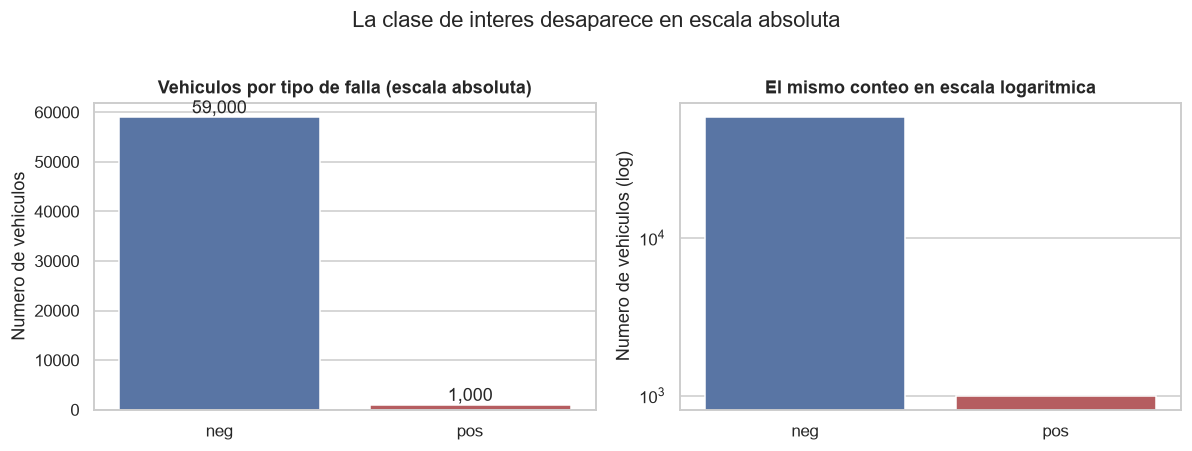

In [8]:
conteo_clases = df[OBJETIVO].value_counts()
prevalencia = 100 * conteo_clases.get("pos", 0) / len(df)
razon_desbalance = conteo_clases.get("neg", 0) / max(conteo_clases.get("pos", 1), 1)

print(conteo_clases.to_string())
print()
print(f"Prevalencia de falla de APS: {prevalencia:.2f} %")
print(f"Por cada vehiculo con falla de APS hay {razon_desbalance:.0f} sin ella")

fig, ejes = plt.subplots(1, 2, figsize=(11, 4))

sns.barplot(
    x=conteo_clases.index, y=conteo_clases.values, ax=ejes[0],
    hue=conteo_clases.index, palette=["#4C72B0", "#C44E52"], legend=False,
)
ejes[0].set_title("Vehiculos por tipo de falla (escala absoluta)")
ejes[0].set_xlabel("")
ejes[0].set_ylabel("Numero de vehiculos")
for i, v in enumerate(conteo_clases.values):
    ejes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

sns.barplot(
    x=conteo_clases.index, y=conteo_clases.values, ax=ejes[1],
    hue=conteo_clases.index, palette=["#4C72B0", "#C44E52"], legend=False,
)
ejes[1].set_yscale("log")
ejes[1].set_title("El mismo conteo en escala logaritmica")
ejes[1].set_xlabel("")
ejes[1].set_ylabel("Numero de vehiculos (log)")

fig.suptitle("La clase de interes desaparece en escala absoluta", y=1.02)
plt.tight_layout()
guardar_figura("01_distribucion_clases")
plt.show()

### 6.7 Lo que cuesta equivocarse, antes de mirar nada mas

Con la prevalencia ya conocida se pueden calcular los dos extremos de la
decision, que sirven como marco de referencia para todo el analisis: **cuanto
cuesta no inspeccionar a nadie y cuanto cuesta inspeccionar a todos.** Cualquier
uso de las lecturas solo tiene sentido si consigue costar menos que ambos.

In [9]:
n_positivos = int(conteo_clases.get("pos", 0))
n_negativos = int(conteo_clases.get("neg", 0))

costo_no_inspeccionar = n_positivos * COSTO_FALLA_NO_DETECTADA
costo_inspeccionar_todo = n_negativos * COSTO_INSPECCION_INNECESARIA

referencia = pd.DataFrame(
    {
        "estrategia": [
            "No inspeccionar ningun vehiculo",
            "Inspeccionar toda la flota",
        ],
        "falsas_alarmas": [0, n_negativos],
        "fallas_no_detectadas": [n_positivos, 0],
        "costo_total": [costo_no_inspeccionar, costo_inspeccionar_todo],
    }
)
referencia["costo_por_vehiculo"] = (referencia["costo_total"] / len(df)).round(2)

print(referencia.to_string(index=False))
print()
print(f"Presupuesto implicito: se pueden pagar hasta {RAZON_COSTOS:.0f} inspecciones")
print("innecesarias por cada falla de APS que se logre detectar a tiempo.")

                     estrategia  falsas_alarmas  fallas_no_detectadas  costo_total  costo_por_vehiculo
No inspeccionar ningun vehiculo               0                  1000       500000                8.33
     Inspeccionar toda la flota           59000                     0       590000                9.83

Presupuesto implicito: se pueden pagar hasta 50 inspecciones
innecesarias por cada falla de APS que se logre detectar a tiempo.


### 6.8 Naturaleza de los datos

La tabla que sigue inventaria las 170 lecturas. La columna de definicion que
acompanaria a un registro con nombres interpretables no puede construirse aqui:
los nombres estan anonimizados y no existe diccionario de variables. Inventar
descripciones seria falsear el analisis, y repetir 170 veces la palabra
"anonimizada" no aporta nada.

En su lugar se documenta lo que si se puede establecer a partir de los datos y
de la estructura de los nombres:

- **Familia**: el prefijo del nombre, que agrupa columnas provenientes de un
  mismo sensor.
- **Rol**: si la columna es una medicion simple o uno de los rangos en que se
  reparte la lectura de un sensor de histograma.
- **Escala de medicion**: determinada por el comportamiento observado de los
  valores, no por su nombre.
- **Observaciones**: senalamientos de calidad detectados en la propia columna.

Esta sustitucion no es una renuncia sino la version honesta de la tabla: es
exactamente la informacion que un analista tiene disponible cuando trabaja con
datos industriales de un tercero.

In [10]:
# Prefijo de cada nombre: identifica el sensor de origen
prefijos = pd.Series([c.split("_")[0] for c in VARIABLES], index=VARIABLES, name="familia")
tamano_familia = prefijos.value_counts()

# Una familia con mas de una columna reparte un mismo sensor en rangos
FAMILIAS_HISTOGRAMA = sorted(tamano_familia[tamano_familia > 1].index)
COLUMNAS_HISTOGRAMA = [c for c in VARIABLES if prefijos[c] in FAMILIAS_HISTOGRAMA]
COLUMNAS_SIMPLES = [c for c in VARIABLES if prefijos[c] not in FAMILIAS_HISTOGRAMA]

print(f"Familias de histograma detectadas: {len(FAMILIAS_HISTOGRAMA)}")
print(tamano_familia[tamano_familia > 1].to_string())
print()
print(f"Columnas que pertenecen a una familia de histograma: {len(COLUMNAS_HISTOGRAMA)}",
      f"({100 * len(COLUMNAS_HISTOGRAMA) / len(VARIABLES):.0f} % del total)")
print(f"Columnas que son mediciones simples: {len(COLUMNAS_SIMPLES)}")

Familias de histograma detectadas: 7
familia
ag    10
ay    10
az    10
ba    10
cn    10
cs    10
ee    10

Columnas que pertenecen a una familia de histograma: 70 (41 % del total)
Columnas que son mediciones simples: 100


In [11]:
def escala_de_medicion(serie):
    """Determina la escala a partir del comportamiento observado de los valores."""
    s = serie.dropna()
    if s.empty:
        return "sin datos"
    if s.nunique() <= 2:
        return "Nominal (binaria de hecho)"
    todos_enteros = bool(np.all(np.equal(np.mod(s.to_numpy(), 1), 0)))
    if todos_enteros:
        return "Razon (discreta)"
    return "Razon (continua)"


filas_naturaleza = []

for columna in VARIABLES:
    familia = prefijos[columna]
    sufijo = columna.split("_")[1]
    if familia in FAMILIAS_HISTOGRAMA:
        rol = f"rango {int(sufijo)} de {tamano_familia[familia]} del sensor {familia}"
    else:
        rol = "medicion simple"

    serie = df[columna]
    pct_faltantes = 100 * serie.isna().mean()
    n_unicos = int(serie.nunique(dropna=True))

    notas = []
    if pct_faltantes > 50:
        notas.append("cobertura insuficiente")
    elif pct_faltantes > 20:
        notas.append("cobertura parcial")
    if n_unicos <= 1:
        notas.append("sin variacion")
    elif n_unicos <= 5:
        notas.append("casi constante")

    filas_naturaleza.append(
        {
            "variable": columna,
            "familia": familia,
            "tipo": str(serie.dtype),
            "rol": rol,
            "escala_medicion": escala_de_medicion(serie),
            "pct_faltantes": round(pct_faltantes, 2),
            "valores_unicos": n_unicos,
            "observaciones": "; ".join(notas) if notas else "sin senalamientos",
        }
    )

naturaleza = pd.DataFrame(filas_naturaleza)

# Fila de la variable objetivo
fila_objetivo = pd.DataFrame(
    [
        {
            "variable": OBJETIVO,
            "familia": "-",
            "tipo": str(df[OBJETIVO].dtype),
            "rol": "variable objetivo",
            "escala_medicion": "Nominal (binaria)",
            "pct_faltantes": round(100 * df[OBJETIVO].isna().mean(), 2),
            "valores_unicos": int(df[OBJETIVO].nunique()),
            "observaciones": "pos = falla en componente del APS; neg = falla en otro sistema",
        }
    ]
)

naturaleza = pd.concat([fila_objetivo, naturaleza], ignore_index=True)
naturaleza.to_csv(os.path.join(RUTA_INTERIM, "naturaleza_datos.csv"), index=False)

print(f"Tabla de naturaleza de los datos: {len(naturaleza)} filas")
naturaleza

Tabla de naturaleza de los datos: 171 filas


,variable,familia,tipo,rol,escala_medicion,pct_faltantes,valores_unicos,observaciones
0,class,-,str,variable objetivo,Nominal (binaria),0.00,2,pos = falla en componente del APS; neg = falla...
1,aa_000,aa,int64,medicion simple,Razon (discreta),0.00,22095,sin senalamientos
2,ab_000,ab,float64,medicion simple,Razon (discreta),77.22,29,cobertura insuficiente
3,ac_000,ac,float64,medicion simple,Razon (discreta),5.56,2061,sin senalamientos
4,ad_000,ad,float64,medicion simple,Razon (discreta),24.77,1886,cobertura parcial
5,ae_000,ae,float64,medicion simple,Razon (discreta),4.17,333,sin senalamientos
6,af_000,af,float64,medicion simple,Razon (discreta),4.17,418,sin senalamientos
7,ag_000,ag,float64,rango 0 de 10 del sensor ag,Razon (discreta),1.12,154,sin senalamientos
8,ag_001,ag,float64,rango 1 de 10 del sensor ag,Razon (discreta),1.12,617,sin senalamientos
9,ag_002,ag,float64,rango 2 de 10 del sensor ag,Razon (discreta),1.12,2422,sin senalamientos


In [12]:
# Sintesis de la tabla anterior
print("Escalas de medicion presentes:")
print(naturaleza["escala_medicion"].value_counts().to_string())
print()
print("Senalamientos de calidad:")
print(naturaleza["observaciones"].value_counts().to_string())

Escalas de medicion presentes:
escala_medicion
Razon (discreta)              163
Razon (continua)                5
Nominal (binaria de hecho)      2
Nominal (binaria)               1

Senalamientos de calidad:
observaciones
sin senalamientos                                                 145
cobertura parcial                                                  15
cobertura insuficiente                                              8
pos = falla en componente del APS; neg = falla en otro sistema      1
sin variacion                                                       1
cobertura parcial; casi constante                                   1


### 6.9 Revision de datos faltantes

La ausencia de datos se examina desde tres angulos, porque cada uno responde una
pregunta distinta del taller:

- **Por variable**: que sensores reportan poco. Determina que lecturas son
  utilizables.
- **Por vehiculo**: cuantas lecturas faltan en un camion tipico. Determina si el
  problema es de sensores especificos o de registros incompletos.
- **Por patron conjunto**: si los sensores dejan de reportar en bloque. Un
  patron en bloque sugiere que la ausencia tiene una causa comun y no es
  aleatoria.

In [13]:
faltantes = pd.DataFrame(
    {
        "variable": VARIABLES,
        "n_faltantes": df[VARIABLES].isna().sum().to_numpy(),
    }
)
faltantes["pct_faltantes"] = 100 * faltantes["n_faltantes"] / len(df)
faltantes["familia"] = faltantes["variable"].map(prefijos)
faltantes = faltantes.sort_values("pct_faltantes", ascending=False).reset_index(drop=True)

pct_global = 100 * df[VARIABLES].isna().to_numpy().sum() / (len(df) * len(VARIABLES))

print(f"Celdas ausentes en el conjunto completo: {pct_global:.2f} %")
print(f"Lecturas con mas del 50 % de ausencia: {(faltantes['pct_faltantes'] > 50).sum()}")
print(f"Lecturas con mas del 20 % de ausencia: {(faltantes['pct_faltantes'] > 20).sum()}")
print(f"Lecturas sin ningun ausente: {(faltantes['pct_faltantes'] == 0).sum()}")
print()
print("Lecturas con cobertura insuficiente (mas del 50 % ausente):")
print(faltantes[faltantes["pct_faltantes"] > 50].to_string(index=False))

Celdas ausentes en el conjunto completo: 8.33 %
Lecturas con mas del 50 % de ausencia: 8
Lecturas con mas del 20 % de ausencia: 24
Lecturas sin ningun ausente: 1

Lecturas con cobertura insuficiente (mas del 50 % ausente):
variable  n_faltantes  pct_faltantes familia
  br_000        49264      82.106667      br
  bq_000        48722      81.203333      bq
  bp_000        47740      79.566667      bp
  bo_000        46333      77.221667      bo
  ab_000        46329      77.215000      ab
  cr_000        46329      77.215000      cr
  bn_000        44009      73.348333      bn
  bm_000        39549      65.915000      bm


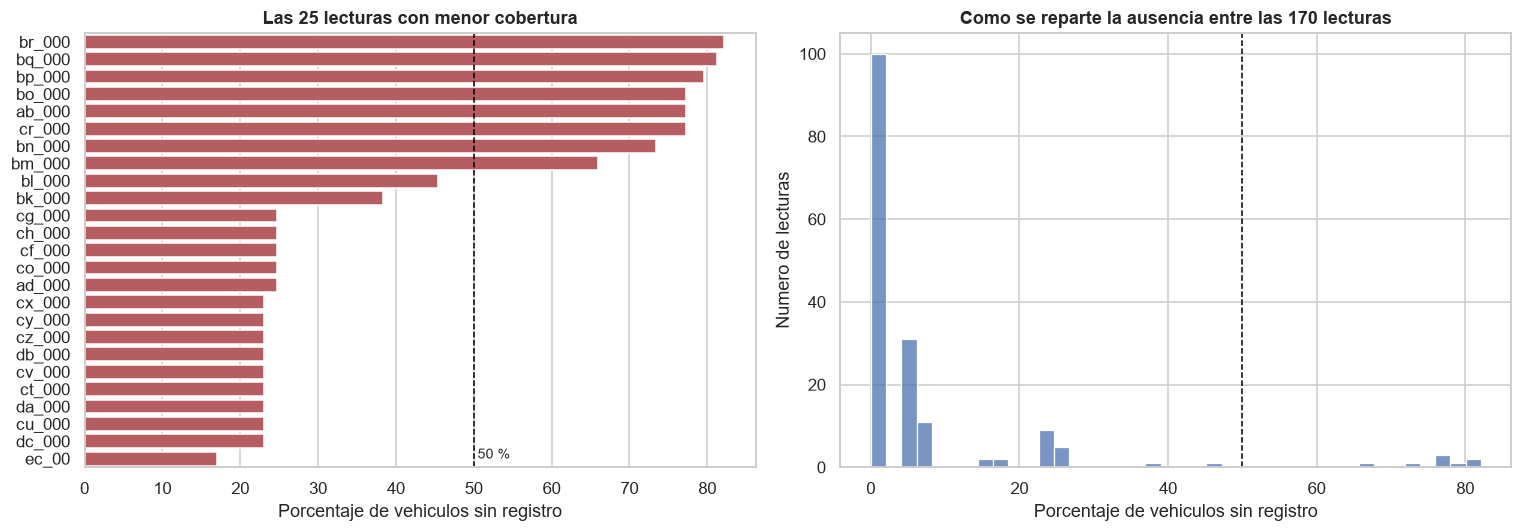

In [14]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

top_faltantes = faltantes.head(25)
sns.barplot(
    data=top_faltantes, y="variable", x="pct_faltantes",
    ax=ejes[0], color="#C44E52",
)
ejes[0].axvline(50, color="black", linestyle="--", linewidth=1)
ejes[0].text(50.5, 24, "50 %", fontsize=9)
ejes[0].set_title("Las 25 lecturas con menor cobertura")
ejes[0].set_xlabel("Porcentaje de vehiculos sin registro")
ejes[0].set_ylabel("")

sns.histplot(data=faltantes, x="pct_faltantes", bins=40, ax=ejes[1], color="#4C72B0")
ejes[1].axvline(50, color="black", linestyle="--", linewidth=1)
ejes[1].set_title("Como se reparte la ausencia entre las 170 lecturas")
ejes[1].set_xlabel("Porcentaje de vehiculos sin registro")
ejes[1].set_ylabel("Numero de lecturas")

plt.tight_layout()
guardar_figura("02_faltantes_por_variable")
plt.show()

Lecturas ausentes por vehiculo:
count    60000.00
mean        14.17
std         16.10
min          0.00
25%          8.00
50%          8.00
75%         16.00
max        168.00

Vehiculos con todas las lecturas completas: 591 (0.98 %)


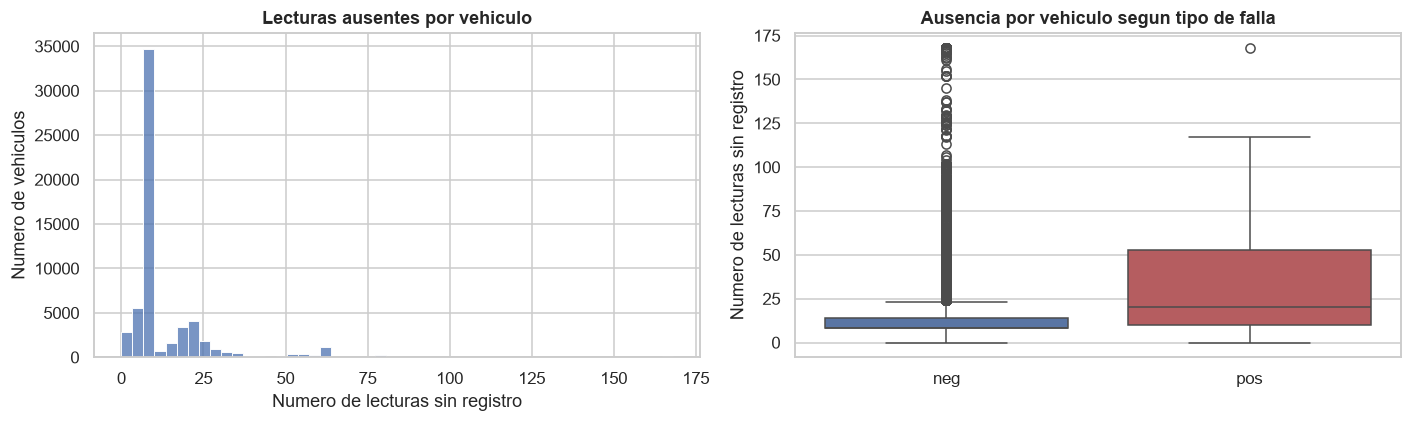

In [15]:
# Ausencia por vehiculo
faltantes_por_vehiculo = df[VARIABLES].isna().sum(axis=1)

print("Lecturas ausentes por vehiculo:")
print(faltantes_por_vehiculo.describe().round(2).to_string())
print()
print(f"Vehiculos con todas las lecturas completas: {(faltantes_por_vehiculo == 0).sum():,}",
      f"({100 * (faltantes_por_vehiculo == 0).mean():.2f} %)")

fig, ejes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(faltantes_por_vehiculo, bins=50, ax=ejes[0], color="#4C72B0")
ejes[0].set_title("Lecturas ausentes por vehiculo")
ejes[0].set_xlabel("Numero de lecturas sin registro")
ejes[0].set_ylabel("Numero de vehiculos")

comparacion = pd.DataFrame(
    {
        "ausentes": faltantes_por_vehiculo,
        "clase": df[OBJETIVO].to_numpy(),
    }
)
sns.boxplot(
    data=comparacion, x="clase", y="ausentes", ax=ejes[1],
    hue="clase", palette=["#4C72B0", "#C44E52"], legend=False,
)
ejes[1].set_title("Ausencia por vehiculo segun tipo de falla")
ejes[1].set_xlabel("")
ejes[1].set_ylabel("Numero de lecturas sin registro")

plt.tight_layout()
guardar_figura("03_faltantes_por_vehiculo")
plt.show()

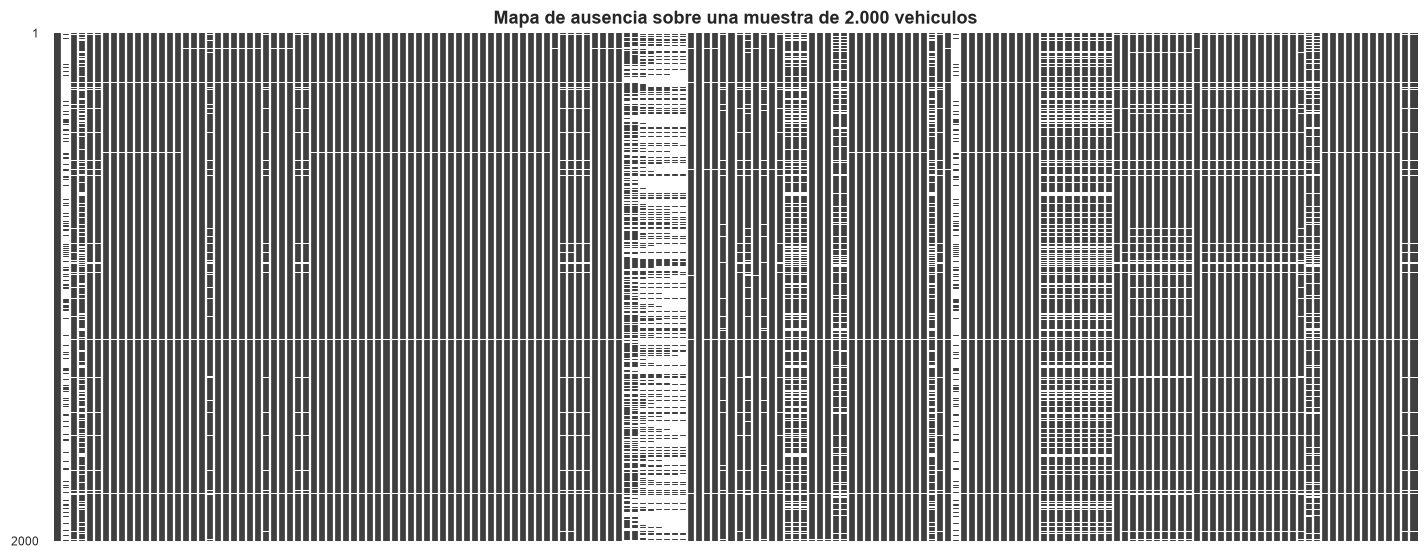

In [16]:
# Mapa de ausencia: cada fila un vehiculo, cada columna una lectura
muestra_mapa = df[VARIABLES].sample(n=min(2000, len(df)), random_state=SEMILLA)

try:
    import missingno as msno

    ax = msno.matrix(muestra_mapa, figsize=(16, 6), fontsize=7, sparkline=False)
    ax.set_title("Mapa de ausencia sobre una muestra de 2.000 vehiculos", fontsize=12)
    guardar_figura("04_mapa_ausencia")
    plt.show()
except Exception as error:
    print("missingno no disponible, se usa alternativa con seaborn:", error)
    plt.figure(figsize=(16, 6))
    sns.heatmap(muestra_mapa.isna(), cbar=False, cmap=["#EAEAF2", "#2F2F2F"])
    plt.title("Mapa de ausencia sobre una muestra de 2.000 vehiculos")
    plt.xlabel("Lecturas")
    plt.ylabel("Vehiculos")
    guardar_figura("04_mapa_ausencia")
    plt.show()

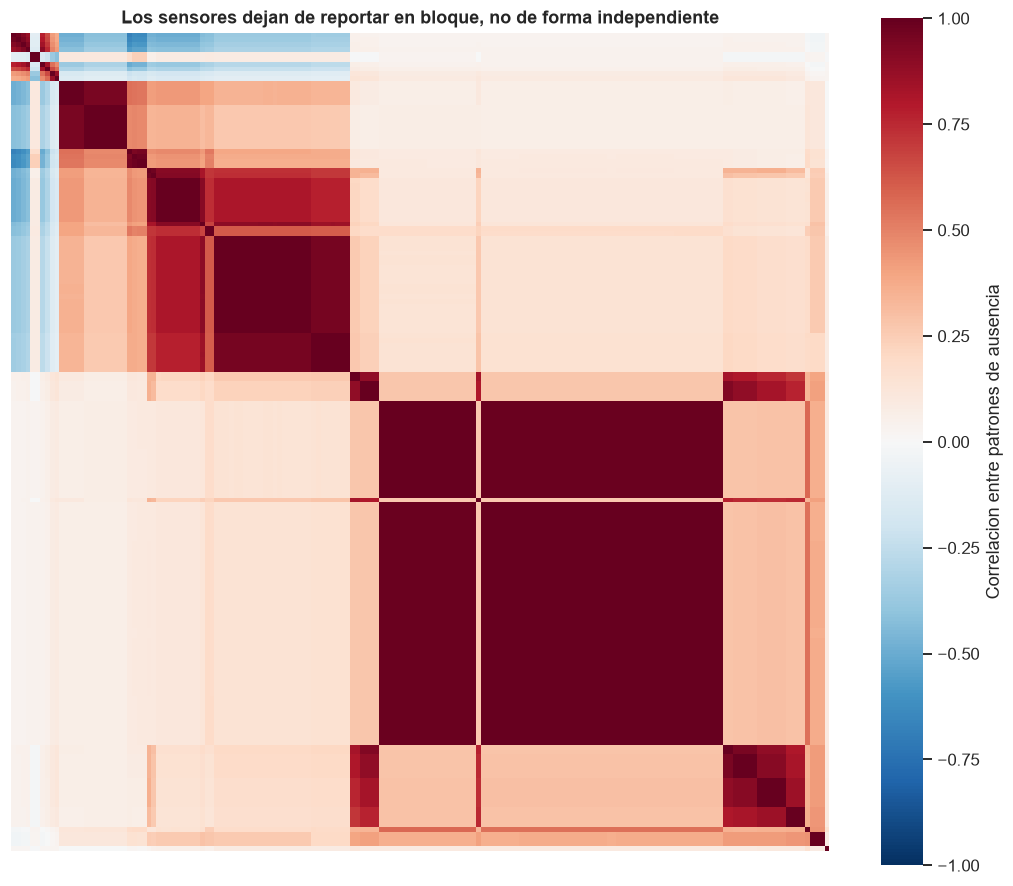

Pares de lecturas cuya ausencia coincide casi perfectamente (r > 0.99): 1760

Diez pares con mayor coincidencia:
bj_000  bi_000    1.0
ao_000  bi_000    1.0
        bj_000    1.0
ci_000  cj_000    1.0
cn_002  cn_004    1.0
        cn_000    1.0
at_000  am_0      1.0
        as_000    1.0
ba_005  ba_000    1.0
        ba_009    1.0


In [17]:
# Ausencia en bloque: correlacion entre los indicadores de ausencia
variables_con_ausencia = faltantes.loc[faltantes["pct_faltantes"] > 0, "variable"].tolist()
indicadores = df[variables_con_ausencia].isna().astype(int)
indicadores = indicadores.loc[:, indicadores.std() > 0]

corr_ausencia = indicadores.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_ausencia, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False, square=True,
            cbar_kws={"label": "Correlacion entre patrones de ausencia"})
plt.title("Los sensores dejan de reportar en bloque, no de forma independiente")
guardar_figura("05_correlacion_ausencia")
plt.show()

# Grupos de variables que faltan siempre juntas
pares_altos = (
    corr_ausencia.where(np.triu(np.ones(corr_ausencia.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
print(f"Pares de lecturas cuya ausencia coincide casi perfectamente (r > 0.99): {(pares_altos > 0.99).sum()}")
print()
print("Diez pares con mayor coincidencia:")
print(pares_altos.head(10).round(3).to_string())

### 6.10 Lectura de la Parte 1

**El registro está esencialmente completo en su columna vertebral.** El 8,33 %
de las celdas está ausente, pero esa cifra global esconde una repartición muy
desigual: 146 de las 170 lecturas tienen menos del 20 % de ausencia, y las 70
columnas que componen los sensores de histograma reportan con un 1,12 % de
ausencia — prácticamente completas. El problema de cobertura está concentrado
en un grupo pequeño y bien delimitado.

**Ocho lecturas no son utilizables tal como están.** Superan el 50 % de
vehículos sin registro y llegan hasta el 82,1 % en el caso de `br_000`. Antes de
descartarlas, sin embargo, hay que resolver si su ausencia es informativa, que
es la pregunta que aborda la sección 14.

**Los sensores no fallan de forma independiente.** La ausencia se organiza en
bloques nítidos, visibles en las cifras exactas de la tabla de naturaleza de los
datos: nueve lecturas comparten exactamente 23,01 % de ausencia, cinco comparten
24,77 %, y las setenta columnas de histograma comparten 1,12 %. Cuando dos
lecturas coinciden hasta el segundo decimal en su tasa de ausencia sobre 60.000
vehículos, no están fallando por separado: están fallando juntas. El mapa de
correlación de patrones de ausencia lo confirma visualmente. Operativamente esto
significa que el problema no son sensores individuales defectuosos sino
subsistemas completos de telemetría que dejan de reportar en bloque.

**Hay una estructura oculta en las lecturas `bk_000` a `br_000`.** Ocho prefijos
consecutivos presentan una ausencia que crece de forma monótona: 38,4 %,
45,5 %, 65,9 %, 73,3 %, 77,2 %, 79,6 %, 81,2 % y 82,1 %. Una escalera tan
regular no es producto del azar. Sugiere que estas ocho columnas forman una
estructura de rangos anidados equivalente a la de los sensores de histograma,
pero que la convención de nombres no declara como familia porque asignó a cada
rango un prefijo propio. Si es así, la ausencia creciente correspondería a
rangos progresivamente más extremos, alcanzados por cada vez menos vehículos.
Es una hipótesis que el análisis no puede confirmar sin conocer el significado
de las variables, pero conviene registrarla porque cambia cómo debe leerse esa
ausencia: no sería falta de cobertura sino ausencia de eventos.

**Una lectura no aporta nada.** `cd_000` registra el mismo valor en los 60.000
vehículos. No puede distinguir entre camiones y queda fuera de todo análisis
posterior por construcción.

**El desbalance define el marco de trabajo.** Con 1.000 vehículos con falla de
APS frente a 59.000 sin ella, y una razón de costos de 50 a 1, las dos
estrategias extremas resultan comparables entre sí y ambas caras: no
inspeccionar a nadie cuesta 500.000 y inspeccionar a toda la flota cuesta
590.000. El margen de mejora existe, pero exige que las lecturas separen
efectivamente a los dos grupos. Esa es la pregunta de la Parte 3.

---

# PARTE 2 — Analisis univariado

Con 170 lecturas anonimizadas, dedicar una seccion a cada una produce un
documento de extension inmanejable y, peor aun, de contenido vacio: sin saber
que mide `bt_000`, el texto que acompana a su histograma solo puede repetir en
palabras los numeros que ya estan en la tabla.

El analisis se organiza entonces en tres niveles, de mayor a menor cobertura:

| Nivel | Alcance | Que responde |
|---|---|---|
| **1. Inventario** | Las 170 lecturas | Como se comporta cada lectura, en una sola tabla |
| **2. Perfiles agregados** | El conjunto como un todo | Que forma tiene el registro completo |
| **3. Detalle selectivo** | Un subconjunto justificado | Que ocurre en los casos que merecen mirarse |

El tercer nivel no recorta por conveniencia: selecciona segun criterios que se
declaran de forma explicita y que son, en si mismos, un resultado de los dos
niveles anteriores.

## 7. Nivel 1 — Inventario completo de las 170 lecturas

Una fila por lectura, con las medidas necesarias para caracterizar su posicion,
dispersion, forma y calidad. Esta tabla cubre la totalidad del registro y es la
base sobre la que se construyen los dos niveles siguientes.

In [18]:
datos_numericos = df[VARIABLES]

resumen = pd.DataFrame(index=VARIABLES)
resumen.index.name = "variable"

resumen["familia"] = [prefijos[c] for c in VARIABLES]
resumen["n_validos"] = datos_numericos.notna().sum()
resumen["pct_faltantes"] = 100 * datos_numericos.isna().mean()
resumen["minimo"] = datos_numericos.min()
resumen["p25"] = datos_numericos.quantile(0.25)
resumen["mediana"] = datos_numericos.median()
resumen["p75"] = datos_numericos.quantile(0.75)
resumen["p99"] = datos_numericos.quantile(0.99)
resumen["maximo"] = datos_numericos.max()
resumen["media"] = datos_numericos.mean()
resumen["desviacion"] = datos_numericos.std()
resumen["asimetria"] = datos_numericos.skew()
resumen["curtosis"] = datos_numericos.kurtosis()
resumen["valores_unicos"] = datos_numericos.nunique()

conteo_ceros = (datos_numericos == 0).sum()
resumen["pct_ceros"] = 100 * conteo_ceros / resumen["n_validos"].replace(0, np.nan)

# Coeficiente de variacion: dispersion relativa, comparable entre lecturas de
# escalas muy distintas
resumen["coef_variacion"] = resumen["desviacion"] / resumen["media"].replace(0, np.nan)

resumen = resumen.round(4)
resumen.to_csv(os.path.join(RUTA_INTERIM, "resumen_univariado.csv"))

print(f"Inventario construido: {len(resumen)} lecturas x {resumen.shape[1]} medidas")
resumen

Inventario construido: 170 lecturas x 16 medidas


,familia,n_validos,pct_faltantes,minimo,p25,mediana,p75,p99,maximo,media,desviacion,asimetria,curtosis,valores_unicos,pct_ceros,coef_variacion
variable,,,,,,,,,,,,,,,,
aa_000,aa,60000,0.0000,0.0,834.00,30776.00,48668.00,8.307366e+05,2.746564e+06,5.933650e+04,1.454301e+05,6.1158,48.2974,22095,0.6550,2.4509
ab_000,ab,13671,77.2150,0.0,0.00,0.00,0.00,8.000000e+00,2.040000e+02,7.132000e-01,3.479000e+00,28.0853,1223.4754,29,80.2941,4.8780
ac_000,ac,56665,5.5583,0.0,16.00,152.00,964.00,2.130706e+09,2.130707e+09,3.560143e+08,7.948749e+08,1.7848,1.1857,2061,15.4452,2.2327
ad_000,ad,45139,24.7683,0.0,24.00,126.00,430.00,4.125240e+03,8.584298e+09,1.906206e+05,4.040441e+07,212.4594,45138.9994,1886,4.4507,211.9624
ae_000,ae,57500,4.1667,0.0,0.00,0.00,0.00,1.180000e+02,2.105000e+04,6.819100e+00,1.615434e+02,90.5883,10761.4306,333,96.5965,23.6897
af_000,af,57500,4.1667,0.0,0.00,0.00,0.00,1.780200e+02,2.007000e+04,1.100680e+01,2.097926e+02,51.6718,3818.5247,418,96.4800,19.0602
ag_000,ag,59329,1.1183,0.0,0.00,0.00,0.00,0.000000e+00,3.376892e+06,2.216364e+02,2.047846e+04,153.3876,24992.2727,154,99.6696,92.3967
ag_001,ag,59329,1.1183,0.0,0.00,0.00,0.00,4.803200e+02,4.109372e+06,9.757223e+02,3.420053e+04,76.0760,7290.5070,617,98.7493,35.0515
ag_002,ag,59329,1.1183,0.0,0.00,0.00,0.00,1.023943e+05,1.055286e+07,8.606014e+03,1.503220e+05,37.0262,1772.5923,2422,94.6940,17.4671


In [19]:
# Ordenes de magnitud presentes en el conjunto
print("Rango de los valores maximos observados entre lecturas:")
print(f"  minimo de los maximos: {resumen['maximo'].min():,.0f}")
print(f"  mediana de los maximos: {resumen['maximo'].median():,.0f}")
print(f"  maximo de los maximos: {resumen['maximo'].max():,.0f}")
print()
print("Esto significa que las lecturas no son comparables entre si en escala bruta;")
print("cualquier grafico conjunto exige normalizar o usar escala logaritmica.")
print()
print("Lecturas con mediana igual a cero (el vehiculo tipico no registra nada):",
      int((resumen["mediana"] == 0).sum()))
print("Lecturas donde mas del 50 % de los registros validos son cero:",
      int((resumen["pct_ceros"] > 50).sum()))

Rango de los valores maximos observados entre lecturas:
  minimo de los maximos: 2
  mediana de los maximos: 22,300,667
  maximo de los maximos: 8,584,297,742

Esto significa que las lecturas no son comparables entre si en escala bruta;
cualquier grafico conjunto exige normalizar o usar escala logaritmica.

Lecturas con mediana igual a cero (el vehiculo tipico no registra nada): 56
Lecturas donde mas del 50 % de los registros validos son cero: 56


## 8. Nivel 2 — Perfiles agregados del conjunto

En lugar de 170 histogramas, cuatro graficos que describen la forma del registro
completo. Cada punto de estas distribuciones es una lectura, no un vehiculo.

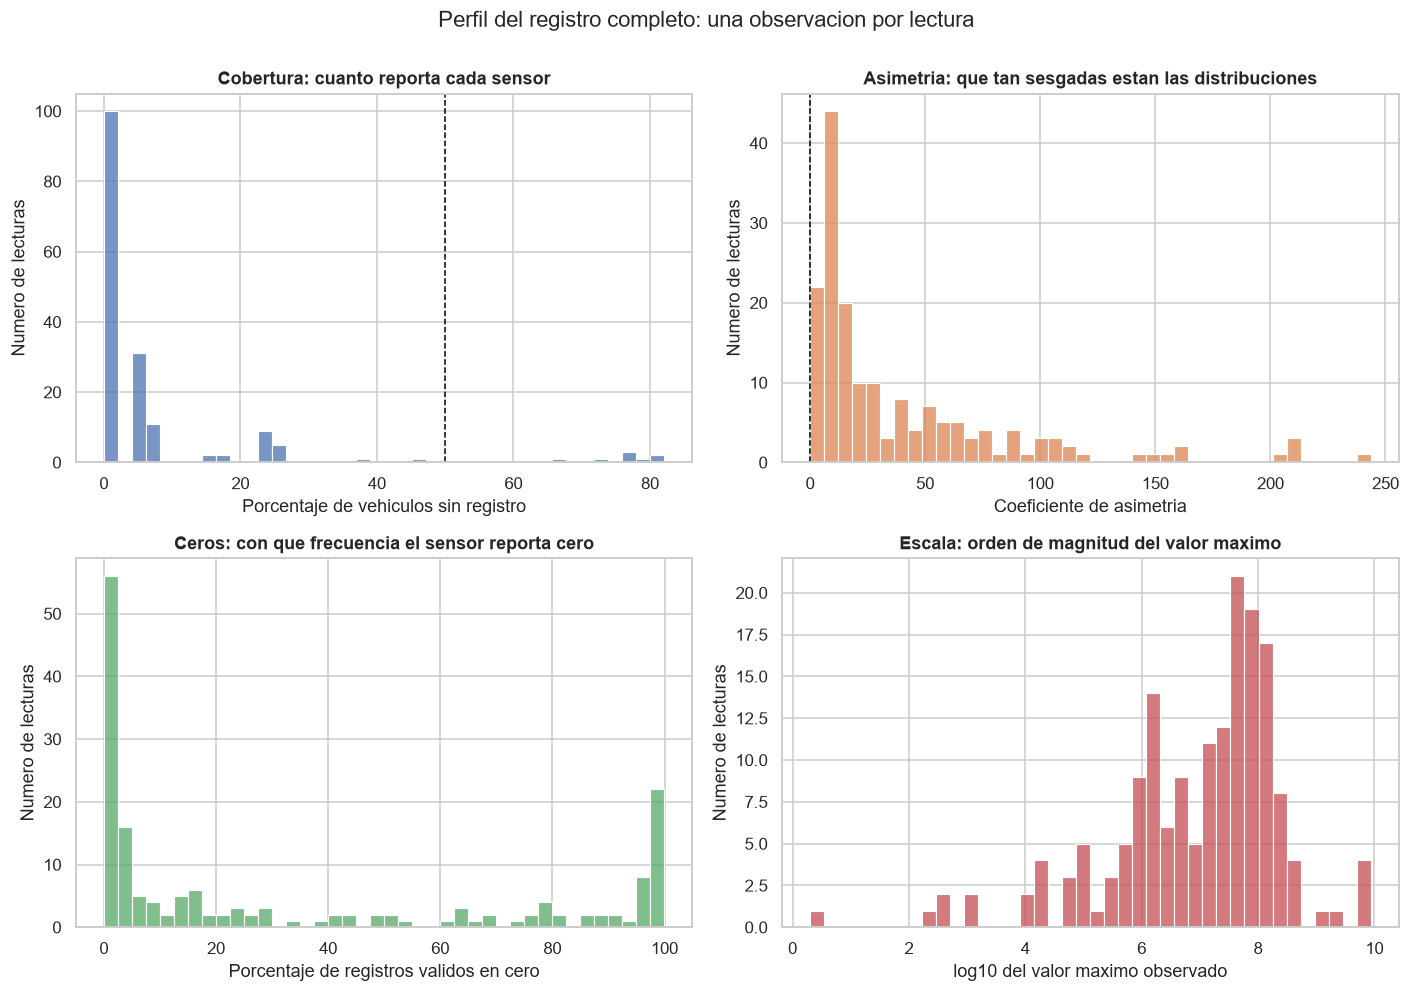

In [20]:
fig, ejes = plt.subplots(2, 2, figsize=(13, 9))

# Cobertura
sns.histplot(resumen["pct_faltantes"], bins=40, ax=ejes[0, 0], color="#4C72B0")
ejes[0, 0].axvline(50, color="black", linestyle="--", linewidth=1)
ejes[0, 0].set_title("Cobertura: cuanto reporta cada sensor")
ejes[0, 0].set_xlabel("Porcentaje de vehiculos sin registro")
ejes[0, 0].set_ylabel("Numero de lecturas")

# Asimetria
sns.histplot(resumen["asimetria"], bins=40, ax=ejes[0, 1], color="#DD8452")
ejes[0, 1].axvline(0, color="black", linestyle="--", linewidth=1)
ejes[0, 1].set_title("Asimetria: que tan sesgadas estan las distribuciones")
ejes[0, 1].set_xlabel("Coeficiente de asimetria")
ejes[0, 1].set_ylabel("Numero de lecturas")

# Ceros
sns.histplot(resumen["pct_ceros"].dropna(), bins=40, ax=ejes[1, 0], color="#55A868")
ejes[1, 0].set_title("Ceros: con que frecuencia el sensor reporta cero")
ejes[1, 0].set_xlabel("Porcentaje de registros validos en cero")
ejes[1, 0].set_ylabel("Numero de lecturas")

# Orden de magnitud
orden_magnitud = np.log10(resumen["maximo"].replace(0, np.nan)).dropna()
sns.histplot(orden_magnitud, bins=40, ax=ejes[1, 1], color="#C44E52")
ejes[1, 1].set_title("Escala: orden de magnitud del valor maximo")
ejes[1, 1].set_xlabel("log10 del valor maximo observado")
ejes[1, 1].set_ylabel("Numero de lecturas")

fig.suptitle("Perfil del registro completo: una observacion por lectura", y=1.00)
plt.tight_layout()
guardar_figura("06_perfiles_agregados")
plt.show()

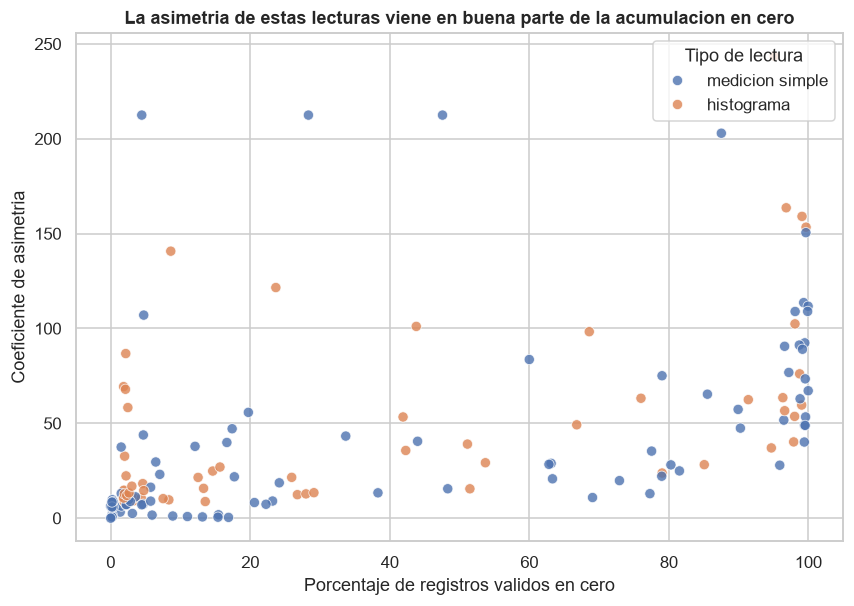

In [21]:
# Relacion entre asimetria y presencia de ceros
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=resumen.reset_index(),
    x="pct_ceros", y="asimetria",
    hue=[("histograma" if c in COLUMNAS_HISTOGRAMA else "medicion simple") for c in resumen.index],
    palette={"histograma": "#DD8452", "medicion simple": "#4C72B0"},
    alpha=0.8, s=45,
)
plt.xlabel("Porcentaje de registros validos en cero")
plt.ylabel("Coeficiente de asimetria")
plt.title("La asimetria de estas lecturas viene en buena parte de la acumulacion en cero")
plt.legend(title="Tipo de lectura")
guardar_figura("07_asimetria_vs_ceros")
plt.show()

## 9. Verificacion de supuestos distribucionales

Antes de calcular cualquier medida de asociacion hay que establecer con que
tipo de distribuciones se esta trabajando. La verificacion no descansa en una
sola fuente de evidencia, por una razon concreta: **con decenas de miles de
observaciones, las pruebas formales de normalidad rechazan la hipotesis nula
ante desviaciones que no tienen ninguna consecuencia practica.** Un valor p
minusculo con este tamano de muestra informa mas sobre el tamano de la muestra
que sobre la forma de la distribucion.

Por eso se combinan tres fuentes:

1. **Prueba formal** de D'Agostino-Pearson, que contrasta conjuntamente
   asimetria y curtosis. Se prefiere sobre Shapiro-Wilk porque esta ultima esta
   limitada a muestras pequenas.
2. **Tamano del efecto**, mediante los propios coeficientes de asimetria y
   curtosis. Se adopta como criterio de normalidad practica que la asimetria
   este contenida en el intervalo de mas menos uno y la curtosis en el de mas
   menos dos.
3. **Evidencia visual**, mediante graficos cuantil-cuantil sobre una seleccion
   de lecturas.

La conclusion de esta seccion determina el coeficiente que se usara en el
analisis bivariado.

In [22]:
filas_normalidad = []

for columna in VARIABLES:
    serie = df[columna].dropna()
    n = len(serie)
    if n < 20 or serie.nunique() < 3:
        filas_normalidad.append(
            {
                "variable": columna, "n": n,
                "estadistico": np.nan, "valor_p": np.nan,
                "asimetria": serie.skew() if n > 2 else np.nan,
                "curtosis": serie.kurtosis() if n > 3 else np.nan,
                "evaluable": False,
            }
        )
        continue
    estadistico, valor_p = stats.normaltest(serie)
    filas_normalidad.append(
        {
            "variable": columna, "n": n,
            "estadistico": estadistico, "valor_p": valor_p,
            "asimetria": serie.skew(), "curtosis": serie.kurtosis(),
            "evaluable": True,
        }
    )

normalidad = pd.DataFrame(filas_normalidad)
normalidad["rechaza_normalidad"] = normalidad["valor_p"] < 0.05
normalidad["normalidad_practica"] = (
    normalidad["asimetria"].abs().le(1) & normalidad["curtosis"].abs().le(2)
)

evaluables = normalidad[normalidad["evaluable"]]

print(f"Lecturas evaluables: {len(evaluables)} de {len(VARIABLES)}")
print()
print("Criterio 1 - prueba formal de D'Agostino-Pearson (alfa = 0.05)")
print(f"  rechazan normalidad: {int(evaluables['rechaza_normalidad'].sum())}",
      f"({100 * evaluables['rechaza_normalidad'].mean():.1f} %)")
print()
print("Criterio 2 - tamano del efecto (|asimetria| <= 1 y |curtosis| <= 2)")
print(f"  compatibles con normalidad practica: {int(evaluables['normalidad_practica'].sum())}",
      f"({100 * evaluables['normalidad_practica'].mean():.1f} %)")
print()
print("Magnitud de la desviacion observada:")
print(f"  asimetria mediana: {evaluables['asimetria'].median():.2f}")
print(f"  asimetria maxima:  {evaluables['asimetria'].max():.2f}")
print(f"  curtosis mediana:  {evaluables['curtosis'].median():.2f}")
print(f"  curtosis maxima:   {evaluables['curtosis'].max():.2f}")

Lecturas evaluables: 168 de 170

Criterio 1 - prueba formal de D'Agostino-Pearson (alfa = 0.05)
  rechazan normalidad: 168 (100.0 %)

Criterio 2 - tamano del efecto (|asimetria| <= 1 y |curtosis| <= 2)
  compatibles con normalidad practica: 6 (3.6 %)

Magnitud de la desviacion observada:
  asimetria mediana: 17.53
  asimetria maxima:  243.53
  curtosis mediana:  590.40
  curtosis maxima:   59315.22


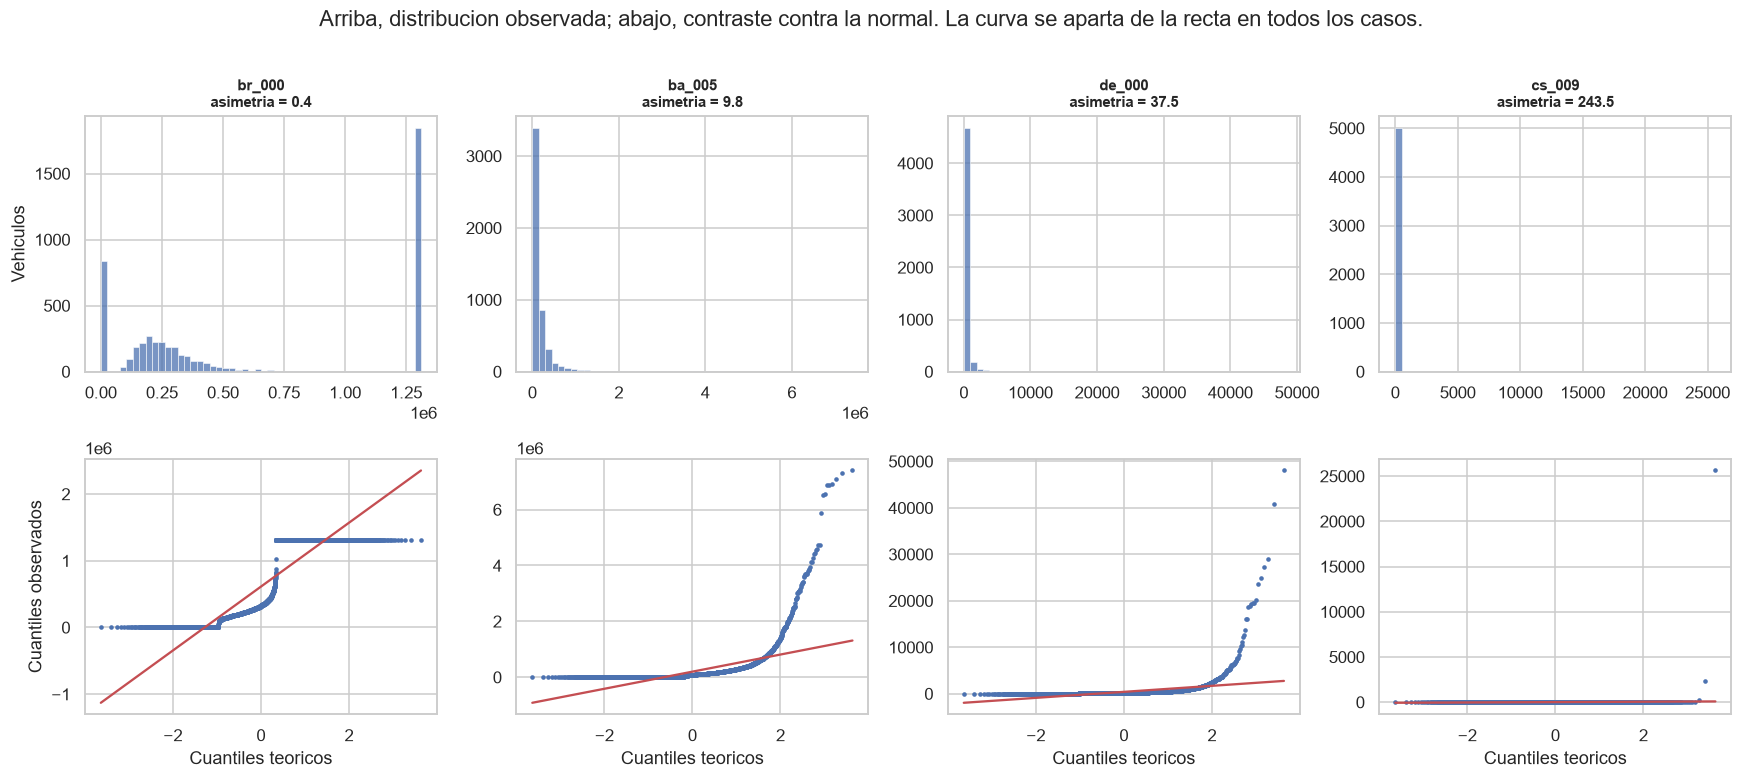

In [23]:
# Evidencia visual: cuatro lecturas de comportamiento representativo
candidatas_qq = (
    resumen.loc[(resumen["n_validos"] > 1000) & (resumen["valores_unicos"] > 50)]
    .sort_values("asimetria")
    .index.tolist()
)
seleccion_qq = [
    candidatas_qq[0],
    candidatas_qq[len(candidatas_qq) // 3],
    candidatas_qq[2 * len(candidatas_qq) // 3],
    candidatas_qq[-1],
]

fig, ejes = plt.subplots(2, 4, figsize=(16, 7))

for j, columna in enumerate(seleccion_qq):
    serie = df[columna].dropna()
    muestra = serie.sample(n=min(5000, len(serie)), random_state=SEMILLA)

    sns.histplot(muestra, bins=50, ax=ejes[0, j], color="#4C72B0")
    ejes[0, j].set_title(f"{columna}\nasimetria = {serie.skew():.1f}", fontsize=10)
    ejes[0, j].set_xlabel("")
    ejes[0, j].set_ylabel("Vehiculos" if j == 0 else "")

    stats.probplot(muestra, dist="norm", plot=ejes[1, j])
    ejes[1, j].set_title("")
    ejes[1, j].get_lines()[0].set_markersize(2)
    ejes[1, j].get_lines()[0].set_color("#4C72B0")
    ejes[1, j].get_lines()[1].set_color("#C44E52")
    ejes[1, j].set_xlabel("Cuantiles teoricos")
    ejes[1, j].set_ylabel("Cuantiles observados" if j == 0 else "")

fig.suptitle(
    "Arriba, distribucion observada; abajo, contraste contra la normal. "
    "La curva se aparta de la recta en todos los casos.",
    y=1.01,
)
plt.tight_layout()
guardar_figura("08_normalidad_qq")
plt.show()

**Consecuencia metodologica.** Las tres fuentes de evidencia coinciden: estas
lecturas no son normales, y la desviacion no es marginal sino estructural — son
conteos acumulados de sensores, con una masa importante en cero y una cola
derecha muy larga. Ninguna transformacion simple las volveria normales sin
distorsionar la interpretacion.

En consecuencia, el analisis bivariado usa **procedimientos no parametricos
basados en rangos**, que no exigen normalidad y son robustos frente a los
valores extremos que caracterizan a estas distribuciones. Concretamente: prueba
de Mann-Whitney para el contraste entre grupos, correlacion de Spearman para la
asociacion entre lecturas.

## 10. Las familias de histograma como unidad de analisis

Siete de los sensores no entregan una medicion sino una distribucion: reparten
sus lecturas en rangos consecutivos, uno por columna. Las columnas `ag_000` a
`ag_009` no son diez variables independientes, son un histograma del sensor
`ag`.

Tratarlas como variables sueltas es un error de lectura con consecuencias
practicas: se pierde la forma del perfil, que es justamente lo que el sensor
esta reportando. Esta seccion las examina como lo que son.

Se verifican tres cosas:

1. **Consistencia interna**: los rangos de una familia se comportan como partes
   de un mismo total.
2. **Ausencia conjunta**: cuando un sensor de histograma no reporta, deja de
   reportar la familia completa o solo algunos rangos.
3. **Forma del perfil**: como se distribuye la masa entre los rangos.

In [24]:
# Composicion de cada familia
composicion = []
for familia in FAMILIAS_HISTOGRAMA:
    columnas_fam = [c for c in VARIABLES if prefijos[c] == familia]
    columnas_fam = sorted(columnas_fam)
    bloque = df[columnas_fam]
    total_fila = bloque.sum(axis=1, min_count=1)
    composicion.append(
        {
            "familia": familia,
            "n_rangos": len(columnas_fam),
            "pct_faltantes_medio": round(100 * bloque.isna().mean().mean(), 2),
            "filas_familia_completa": int(bloque.notna().all(axis=1).sum()),
            "filas_familia_vacia": int(bloque.isna().all(axis=1).sum()),
            "filas_parcialmente_vacia": int(
                (bloque.isna().any(axis=1) & bloque.notna().any(axis=1)).sum()
            ),
            "total_mediano": round(float(total_fila.median()), 1),
            "total_maximo": round(float(total_fila.max()), 1),
        }
    )

composicion = pd.DataFrame(composicion)
print("Las familias no reportan por rangos sueltos sino en bloque:")
composicion

Las familias no reportan por rangos sueltos sino en bloque:


,familia,n_rangos,pct_faltantes_medio,filas_familia_completa,filas_familia_vacia,filas_parcialmente_vacia,total_mediano,total_maximo
0,ag,10,1.12,59329,671,0,2136514.0,568378126.0
1,ay,10,1.12,59329,671,0,2136424.0,568378126.0
2,az,10,1.12,59329,671,0,2136424.0,568378126.0
3,ba,10,1.15,59312,688,0,2137650.0,568378126.0
4,cn,10,1.14,59313,687,0,2137702.0,568378126.0
5,cs,10,1.11,59331,669,0,2136514.0,568378126.0
6,ee,10,1.12,59329,671,0,2136424.0,568378126.0


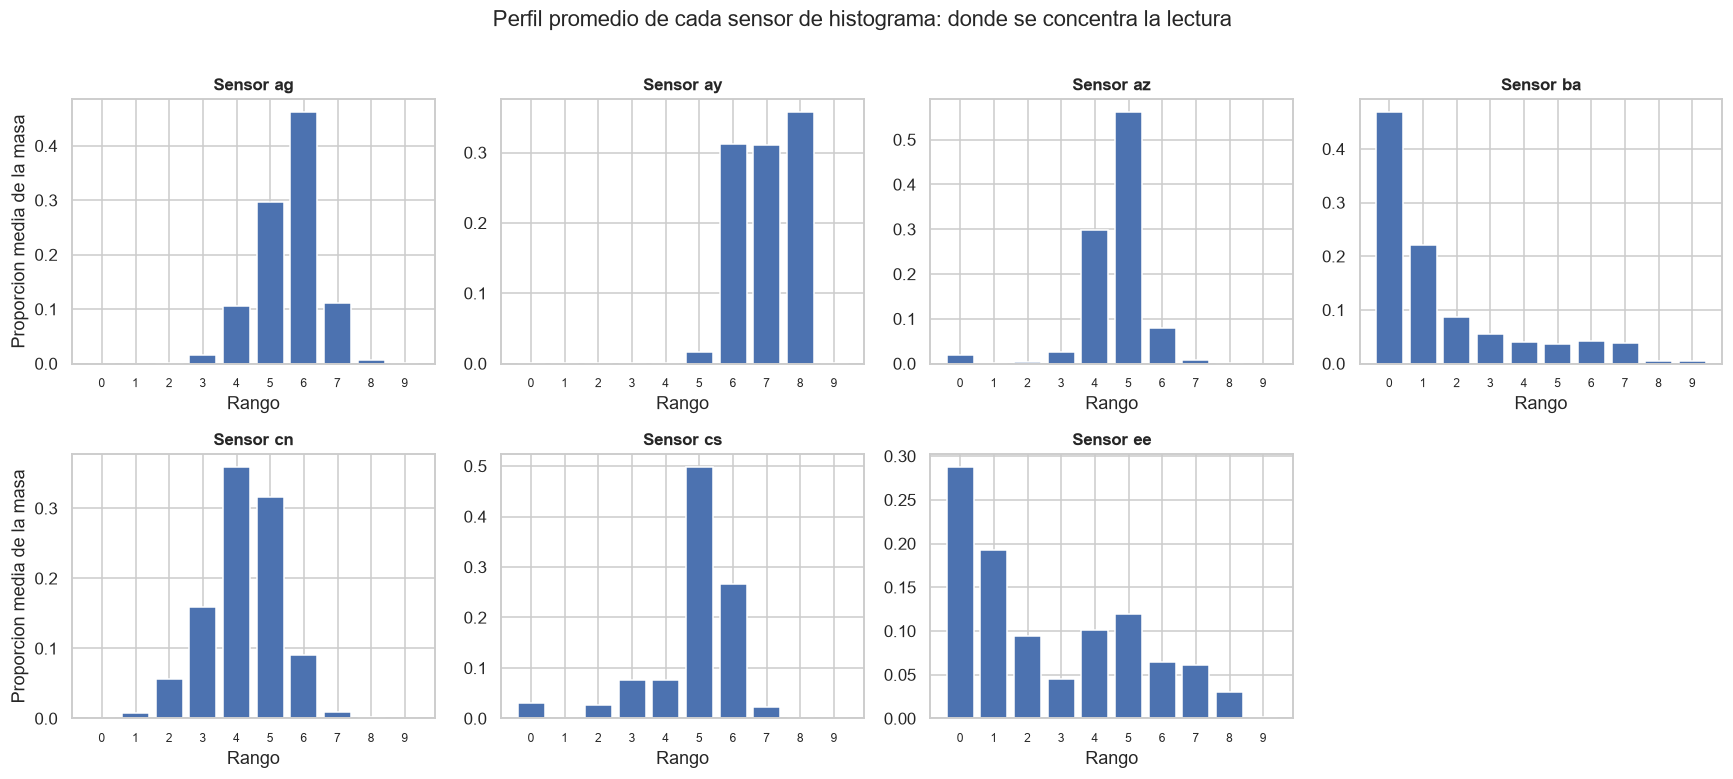

In [25]:
# Perfil promedio de cada familia: como se reparte la masa entre rangos
fig, ejes = plt.subplots(2, 4, figsize=(16, 7))
ejes = ejes.ravel()

for k, familia in enumerate(FAMILIAS_HISTOGRAMA):
    columnas_fam = sorted([c for c in VARIABLES if prefijos[c] == familia])
    bloque = df[columnas_fam]
    total_fila = bloque.sum(axis=1, min_count=1)

    # Perfil normalizado: proporcion de la masa en cada rango, por vehiculo
    validos = total_fila > 0
    proporciones = bloque.loc[validos].div(total_fila.loc[validos], axis=0)
    perfil = proporciones.mean()

    ejes[k].bar(range(len(columnas_fam)), perfil.to_numpy(), color="#4C72B0")
    ejes[k].set_title(f"Sensor {familia}", fontsize=11)
    ejes[k].set_xlabel("Rango")
    ejes[k].set_ylabel("Proporcion media de la masa" if k % 4 == 0 else "")
    ejes[k].set_xticks(range(len(columnas_fam)))
    ejes[k].set_xticklabels(range(len(columnas_fam)), fontsize=8)

for k in range(len(FAMILIAS_HISTOGRAMA), len(ejes)):
    ejes[k].axis("off")

fig.suptitle(
    "Perfil promedio de cada sensor de histograma: donde se concentra la lectura",
    y=1.01,
)
plt.tight_layout()
guardar_figura("09_perfiles_familias")
plt.show()

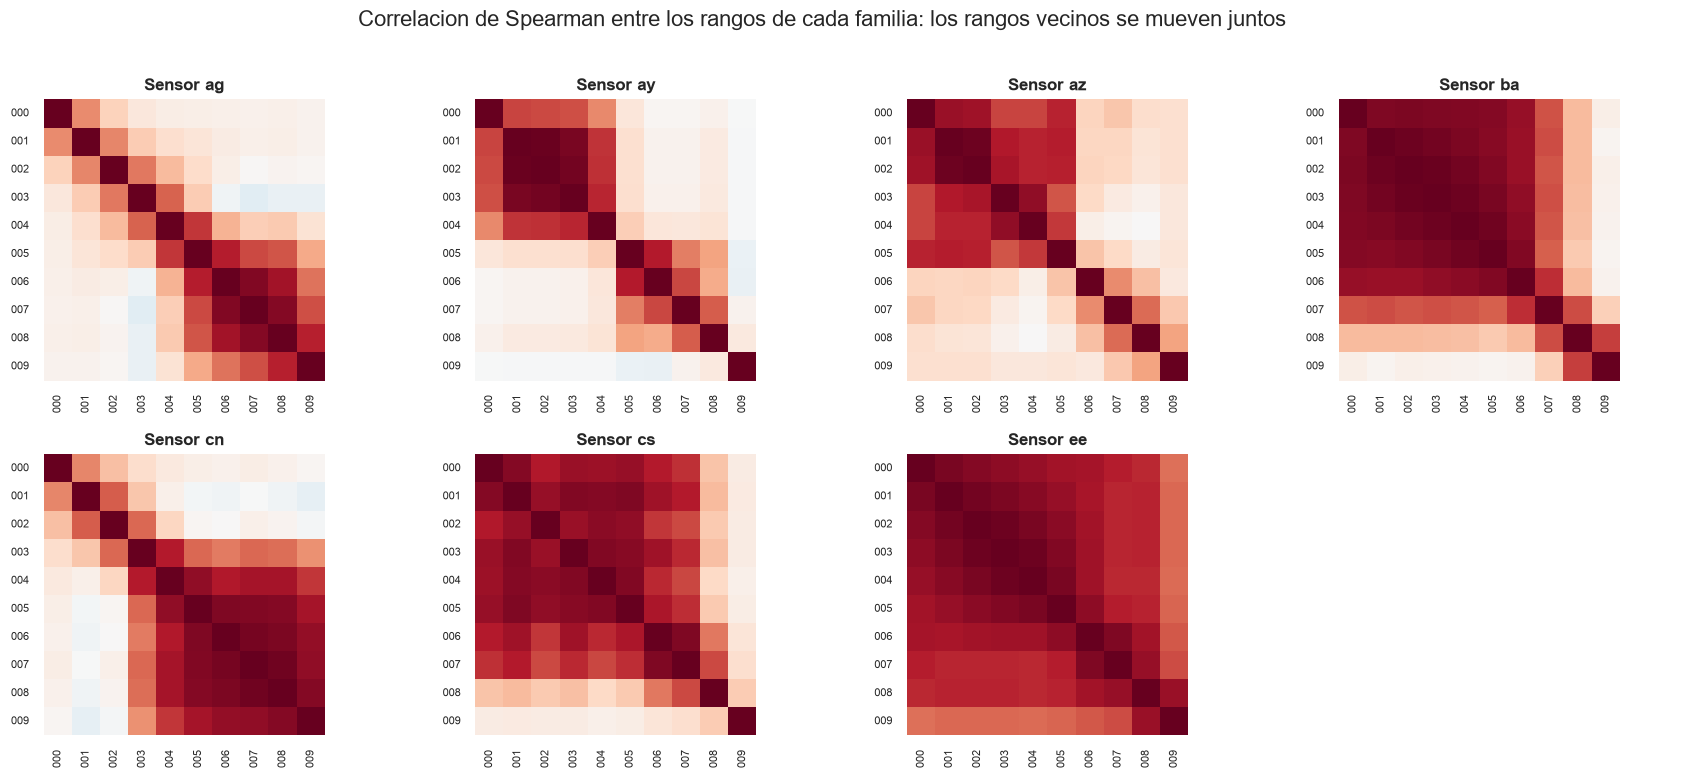

In [26]:
# Correlacion interna: los rangos de una familia se mueven juntos
fig, ejes = plt.subplots(2, 4, figsize=(16, 7))
ejes = ejes.ravel()

for k, familia in enumerate(FAMILIAS_HISTOGRAMA):
    columnas_fam = sorted([c for c in VARIABLES if prefijos[c] == familia])
    corr_interna = df[columnas_fam].corr(method="spearman")
    sns.heatmap(
        corr_interna, ax=ejes[k], cmap="RdBu_r", center=0, vmin=-1, vmax=1,
        cbar=False, square=True,
        xticklabels=[c.split("_")[1] for c in columnas_fam],
        yticklabels=[c.split("_")[1] for c in columnas_fam],
    )
    ejes[k].set_title(f"Sensor {familia}", fontsize=11)
    ejes[k].tick_params(labelsize=7)

for k in range(len(FAMILIAS_HISTOGRAMA), len(ejes)):
    ejes[k].axis("off")

fig.suptitle(
    "Correlacion de Spearman entre los rangos de cada familia: los rangos vecinos se mueven juntos",
    y=1.01,
)
plt.tight_layout()
guardar_figura("10_correlacion_interna_familias")
plt.show()

## 11. Nivel 3 — Detalle selectivo

Los dos niveles anteriores permiten ahora seleccionar que lecturas merecen un
examen individual. El criterio no es arbitrario ni de conveniencia: cada lectura
seleccionada entra por una razon que se registra junto a ella.

Los criterios son cuatro:

- **Cobertura insuficiente**: las lecturas con mas ausencia. Definen que parte
  del registro no es utilizable.
- **Comportamiento extremo**: curtosis mas alta. Identifican lecturas dominadas
  por unos pocos vehiculos atipicos.
- **Variacion insuficiente**: lecturas casi constantes, que no pueden distinguir
  entre vehiculos por construccion.
- **Representante de familia**: el rango de mayor dispersion de cada sensor de
  histograma, como muestra del comportamiento de su familia.

In [27]:
seleccion = {}


def marcar(columna, motivo):
    """Registra una lectura para examen individual, acumulando motivos."""
    if columna in seleccion:
        if motivo not in seleccion[columna]:
            seleccion[columna].append(motivo)
    else:
        seleccion[columna] = [motivo]


# Criterio 1: cobertura insuficiente
for columna in resumen.sort_values("pct_faltantes", ascending=False).head(5).index:
    marcar(columna, "cobertura insuficiente")

# Criterio 2: comportamiento extremo
for columna in resumen.sort_values("curtosis", ascending=False).head(4).index:
    marcar(columna, "curtosis extrema")

# Criterio 3: variacion insuficiente
casi_constantes = resumen[resumen["valores_unicos"] <= 5].index.tolist()
for columna in casi_constantes[:4]:
    marcar(columna, "variacion insuficiente")

# Criterio 4: representante de cada familia de histograma
for familia in FAMILIAS_HISTOGRAMA:
    columnas_fam = [c for c in VARIABLES if prefijos[c] == familia]
    representante = resumen.loc[columnas_fam, "desviacion"].idxmax()
    marcar(representante, f"representante del sensor {familia}")

tabla_seleccion = pd.DataFrame(
    [{"variable": c, "motivos": "; ".join(m)} for c, m in seleccion.items()]
)
tabla_seleccion = tabla_seleccion.merge(
    resumen[["pct_faltantes", "mediana", "maximo", "asimetria", "curtosis",
             "pct_ceros", "valores_unicos"]].reset_index(),
    on="variable", how="left",
).sort_values("variable").reset_index(drop=True)

print(f"Lecturas seleccionadas para examen individual: {len(tabla_seleccion)}",
      f"de {len(VARIABLES)} ({100 * len(tabla_seleccion) / len(VARIABLES):.0f} %)")
tabla_seleccion

Lecturas seleccionadas para examen individual: 18 de 170 (11 %)


,variable,motivos,pct_faltantes,mediana,maximo,asimetria,curtosis,pct_ceros,valores_unicos
0,ab_000,cobertura insuficiente,77.2150,0.0,2.040000e+02,28.0853,1223.4754,80.2941,29
1,ad_000,curtosis extrema,24.7683,126.0,8.584298e+09,212.4594,45138.9994,4.4507,1886
2,ag_006,representante del sensor ag,1.1183,930336.0,9.402067e+07,8.2721,94.7184,2.0867,40615
3,ay_007,representante del sensor ay,1.1183,348622.0,4.896782e+08,21.4707,1483.6794,12.5268,38651
4,az_005,representante del sensor az,1.1183,527034.0,4.678323e+08,12.7547,515.3169,1.9029,44601
5,ba_000,representante del sensor ba,1.1467,679486.0,2.328717e+08,11.3671,323.7383,1.8361,44840
6,bo_000,cobertura insuficiente,77.2217,270660.0,1.310700e+06,0.8600,-1.0228,10.9973,5838
7,bp_000,cobertura insuficiente,79.5667,288320.0,1.310700e+06,0.6661,-1.3446,13.1485,4968
8,bq_000,cobertura insuficiente,81.2033,305100.0,1.310700e+06,0.5133,-1.5409,15.3751,4276
9,br_000,cobertura insuficiente,82.1067,320400.0,1.310700e+06,0.4122,-1.6447,16.8871,3806


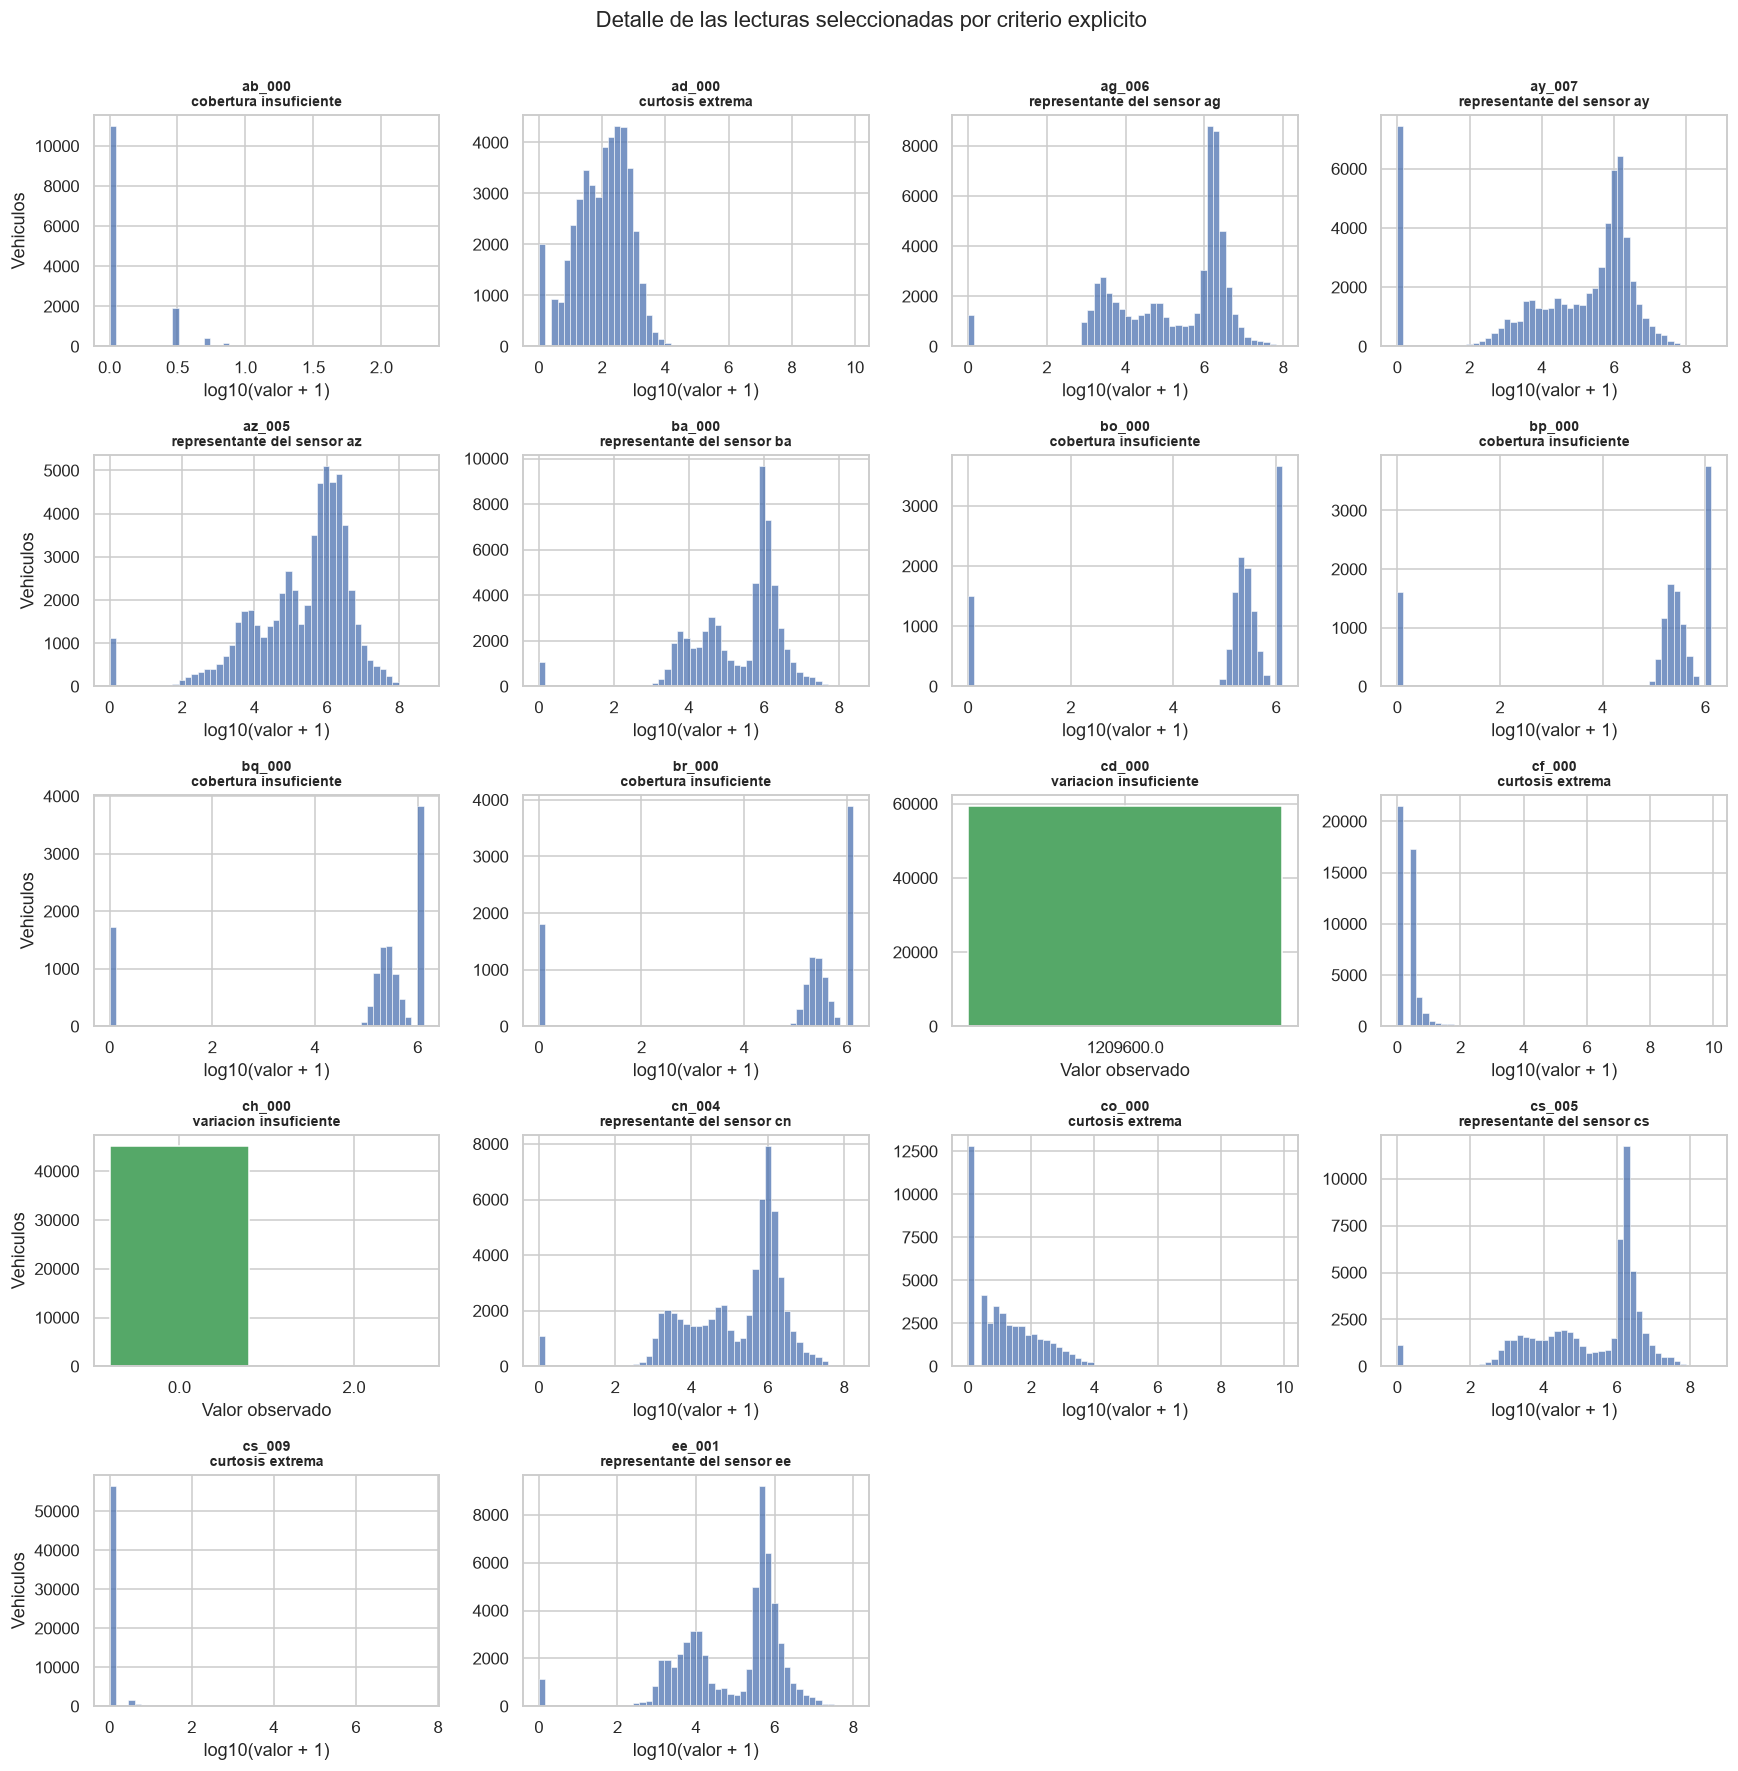

In [28]:
# Un grafico por lectura seleccionada.
# Se usa escala logaritmica desplazada porque las colas cubren varios ordenes de
# magnitud y en escala lineal el grafico se reduce a una barra en el origen.
columnas_seleccionadas = tabla_seleccion["variable"].tolist()
n_graficos = len(columnas_seleccionadas)
n_columnas = 4
n_filas = int(np.ceil(n_graficos / n_columnas))

fig, ejes = plt.subplots(n_filas, n_columnas, figsize=(16, 3.2 * n_filas))
ejes = np.atleast_1d(ejes).ravel()

for k, columna in enumerate(columnas_seleccionadas):
    serie = df[columna].dropna()
    if serie.nunique() <= 5:
        conteos = serie.value_counts().sort_index()
        ejes[k].bar(conteos.index.astype(str), conteos.to_numpy(), color="#55A868")
        ejes[k].set_xlabel("Valor observado")
    else:
        sns.histplot(np.log10(serie + 1), bins=50, ax=ejes[k], color="#4C72B0")
        ejes[k].set_xlabel("log10(valor + 1)")
    motivo = seleccion[columna][0]
    ejes[k].set_title(f"{columna}\n{motivo}", fontsize=9)
    ejes[k].set_ylabel("Vehiculos" if k % n_columnas == 0 else "")

for k in range(n_graficos, len(ejes)):
    ejes[k].axis("off")

fig.suptitle("Detalle de las lecturas seleccionadas por criterio explicito", y=1.005)
plt.tight_layout()
guardar_figura("11_detalle_selectivo")
plt.show()

## 11.1 Lectura de la Parte 2

**La estructura de histograma se confirma.** Las siete familias detectadas
tienen exactamente diez rangos cada una y suman 70 columnas, el 41 % del
registro. Sus rangos vecinos correlacionan fuertemente entre sí y sus perfiles
promedio tienen la forma esperable de una distribución: masa concentrada en los
rangos centrales y colas hacia los extremos. Además reportan en bloque —o está
disponible la familia completa, o no está ninguno de sus rangos—, lo que
confirma que son un solo sensor y no diez.

**Ninguna de las lecturas se aproxima a una distribución normal, y la desviación
no es marginal.** Las tres fuentes de evidencia coinciden sin ambigüedad:

- La prueba formal de D'Agostino-Pearson rechaza la normalidad en las 168
  lecturas evaluables, el 100 %.
- El criterio de tamaño del efecto la descarta en el 96,4 %: solo seis lecturas
  quedan dentro de los umbrales de asimetría y curtosis fijados.
- Los gráficos cuantil-cuantil muestran curvas que se despegan de la recta de
  referencia por completo en la cola derecha.

La coincidencia importa metodológicamente. Con 60.000 observaciones, un rechazo
de la prueba formal por sí solo no significaría nada: cualquier desviación
minúscula produce un valor p despreciable. Lo que sostiene la conclusión es la
magnitud. La asimetría mediana es de 17,5 y llega a 243,5; la curtosis mediana
es de 590 y alcanza 59.315. Una curtosis de ese orden sobre 60.000 vehículos
significa que la forma de la distribución está determinada por un puñado de
registros extremos. No se trata de datos "no perfectamente normales" sino de
distribuciones de una naturaleza distinta: contadores acumulados, con masa
concentrada cerca de cero y colas que se extienden varios órdenes de magnitud.

**Consecuencia directa sobre el resto del análisis.** Toda técnica que suponga
normalidad o que se apoye en medias y varianzas quedaría dominada por unos pocos
vehículos atípicos. La Parte 3 usa en consecuencia procedimientos basados en
rangos, que son invariantes ante transformaciones monótonas y no se ven
arrastrados por las colas. Esta no es una precaución formal: es la diferencia
entre medir lo que ocurre en la flota y medir lo que ocurre en tres camiones.

**Las escalas no son comparables entre lecturas.** Los valores máximos
observados se reparten entre varios órdenes de magnitud, de modo que ningún
gráfico conjunto tiene sentido en escala bruta. Todas las visualizaciones
posteriores usan escala logarítmica desplazada o normalizan cada lectura a su
propio total.

---

# PARTE 3 — Analisis bivariado

Esta parte contrasta la variable objetivo contra cada una de las demas, y
solamente eso. La pregunta que se responde es una sola, repetida 170 veces:
**los camiones con falla en el APS se ven distintos, en esta lectura, de los
camiones cuya falla esta en otro sistema.**

## 12. Por que no una matriz de correlaciones

La variable objetivo es binaria. Calcular un coeficiente de correlacion lineal
entre una lectura continua y una etiqueta de dos categorias es aritmeticamente
posible, pero responde mal la pregunta: la correlacion mide co-variacion lineal,
y aqui no hay una recta que ajustar sino dos poblaciones que comparar.

El planteamiento correcto es de **separacion entre grupos**, y consta de tres
piezas que responden cosas distintas:

| Pieza | Que responde |
|---|---|
| Comparacion de distribuciones | Como se ven los dos grupos en esta lectura |
| Prueba de Mann-Whitney | La diferencia observada es atribuible al azar |
| Correlacion biserial de rangos | Que tan grande es la separacion |

Se usa Mann-Whitney y no la prueba t de Student porque la Parte 2 establecio que
estas distribuciones no son normales ni remotamente, y porque sus colas largas
harian que unos pocos vehiculos extremos dominaran cualquier comparacion de
medias. Mann-Whitney trabaja sobre rangos y es inmune a eso.

La medida de tamano del efecto que acompana a la prueba es la **correlacion
biserial de rangos**, que se deriva directamente del estadistico de la prueba y
se interpreta en una escala acotada entre menos uno y uno. Un valor de cero
significa que un vehiculo tomado al azar de cada grupo tiene la misma
probabilidad de superar al otro; un valor cercano a uno significa que los
vehiculos con falla de APS registran sistematicamente valores mas altos en esa
lectura.

## 13. Sobre la significancia y la correccion por comparaciones multiples

Se contrastan 170 lecturas de forma simultanea. Con un nivel de significancia
del cinco por ciento y sin correccion alguna, cabria esperar cerca de nueve
lecturas declaradas significativas por puro azar. Los valores p se corrigen
entonces por el procedimiento de **Benjamini-Hochberg**, que controla la
proporcion esperada de falsos hallazgos entre los declarados significativos.

Se prefiere sobre la correccion de Bonferroni porque esta ultima controla la
probabilidad de cometer siquiera un error, un objetivo demasiado estricto para
un analisis exploratorio: con 170 contrastes, Bonferroni descartaria
asociaciones de magnitud moderada que aqui interesa conservar.

Hay que anticipar, sin embargo, el reverso del problema que motivo la
verificacion de normalidad. Con sesenta mil vehiculos, **la significancia deja
de discriminar**: diferencias irrelevantes para el taller apareceran con valores
p practicamente nulos. Por eso los resultados se **ordenan por magnitud del
efecto, no por valor p**. Son dos preguntas distintas y ninguna sustituye a la
otra: el valor p corregido indica que la asociacion probablemente no es azar; el
tamano del efecto indica si importa.

In [29]:
# Etiqueta binaria: 1 si el vehiculo tuvo falla en un componente del APS
y = (df[OBJETIVO] == "pos").astype(int)
mascara_positivos = y == 1

n_pos = int(mascara_positivos.sum())
n_neg = int((~mascara_positivos).sum())

print(f"Vehiculos con falla de APS: {n_pos:,}")
print(f"Vehiculos con falla en otro sistema: {n_neg:,}")

Vehiculos con falla de APS: 1,000
Vehiculos con falla en otro sistema: 59,000


## 14. La ausencia de registro como informacion

Antes de comparar valores conviene resolver una pregunta previa que la Parte 1
dejo planteada: **el hecho de que un sensor no reporte, dice algo sobre el
estado del vehiculo.**

Si la ausencia fuera un accidente de la telemetria, su frecuencia seria
equivalente en los dos grupos. Si no lo es, entonces la ausencia es en si misma
una senal, y descartar las lecturas con poca cobertura eliminaria informacion
util en lugar de ruido. La pregunta tiene consecuencias operativas directas
sobre que se hace con las lecturas de cobertura insuficiente.

Se contrasta con una prueba de chi cuadrado por lectura, con la misma correccion
por comparaciones multiples que el resto del analisis.

In [30]:
filas_ausencia = []

for columna in VARIABLES:
    ausente = df[columna].isna()
    if ausente.sum() == 0 or ausente.all():
        continue
    tabla = pd.crosstab(ausente, y)
    if tabla.shape != (2, 2):
        continue
    chi2, valor_p, _, _ = stats.chi2_contingency(tabla)
    tasa_pos = 100 * ausente[mascara_positivos].mean()
    tasa_neg = 100 * ausente[~mascara_positivos].mean()
    filas_ausencia.append(
        {
            "variable": columna,
            "pct_ausente_con_falla": tasa_pos,
            "pct_ausente_sin_falla": tasa_neg,
            "diferencia_pp": tasa_pos - tasa_neg,
            "chi2": chi2,
            "valor_p": valor_p,
        }
    )

ausencia_informativa = pd.DataFrame(filas_ausencia)

rechazo, p_ajustado, _, _ = multipletests(
    ausencia_informativa["valor_p"].to_numpy(), alpha=0.05, method="fdr_bh"
)
ausencia_informativa["valor_p_bh"] = p_ajustado
ausencia_informativa["significativa_bh"] = rechazo

ausencia_informativa = ausencia_informativa.reindex(
    ausencia_informativa["diferencia_pp"].abs().sort_values(ascending=False).index
).reset_index(drop=True)

print(f"Lecturas con ausencia contrastable: {len(ausencia_informativa)}")
print(f"Con diferencia significativa tras Benjamini-Hochberg: "
      f"{int(ausencia_informativa['significativa_bh'].sum())}")
print()
print("Las quince mayores diferencias en tasa de ausencia entre grupos:")
print(
    ausencia_informativa.head(15)
    .round({"pct_ausente_con_falla": 2, "pct_ausente_sin_falla": 2,
            "diferencia_pp": 2, "chi2": 1})
    .assign(valor_p_bh=lambda t: t["valor_p_bh"].map("{:.2e}".format))
    .to_string(index=False)
)

Lecturas con ausencia contrastable: 169
Con diferencia significativa tras Benjamini-Hochberg: 94

Las quince mayores diferencias en tasa de ausencia entre grupos:
variable  pct_ausente_con_falla  pct_ausente_sin_falla  diferencia_pp   chi2  valor_p valor_p_bh  significativa_bh
  br_000                    9.0                  83.35         -74.35 3694.4      0.0   0.00e+00              True
  bq_000                    8.7                  82.43         -73.73 3497.5      0.0   0.00e+00              True
  bp_000                    8.3                  80.77         -72.47 3172.4      0.0   0.00e+00              True
  bo_000                    7.8                  78.40         -70.60 2782.3      0.0   0.00e+00              True
  bn_000                    7.4                  74.47         -67.07 2259.1      0.0   0.00e+00              True
  bm_000                    7.1                  66.91         -59.81 1563.1      0.0   0.00e+00              True
  ak_000                   53.2 

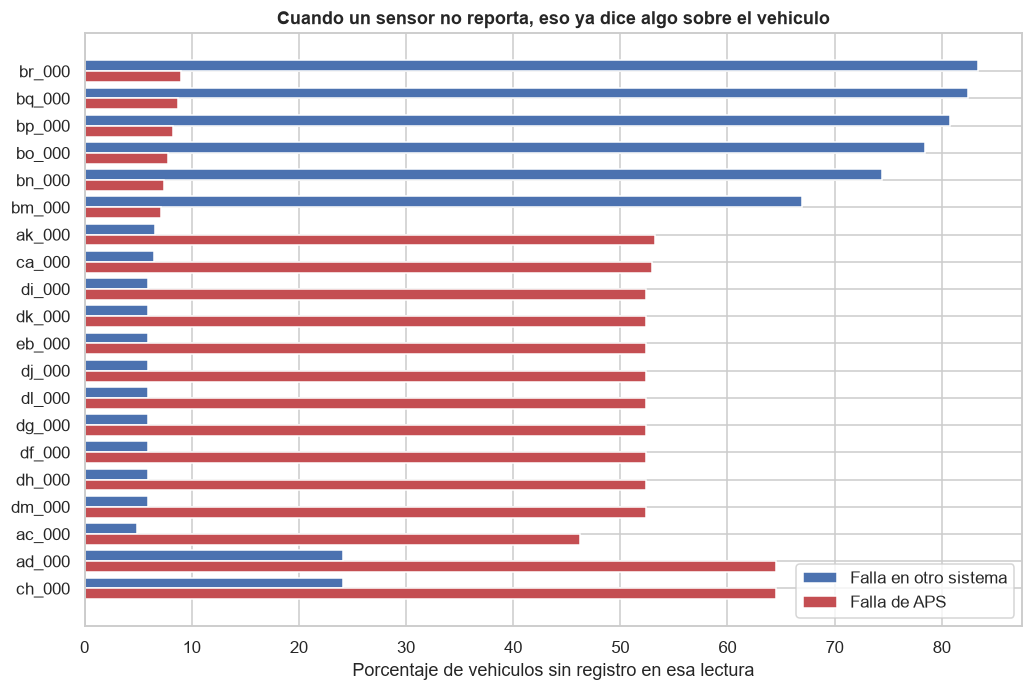

In [31]:
top_ausencia = ausencia_informativa.head(20).copy()

plt.figure(figsize=(11, 7))
posiciones = np.arange(len(top_ausencia))
ancho = 0.4
plt.barh(posiciones - ancho / 2, top_ausencia["pct_ausente_sin_falla"],
         height=ancho, label="Falla en otro sistema", color="#4C72B0")
plt.barh(posiciones + ancho / 2, top_ausencia["pct_ausente_con_falla"],
         height=ancho, label="Falla de APS", color="#C44E52")
plt.yticks(posiciones, top_ausencia["variable"])
plt.gca().invert_yaxis()
plt.xlabel("Porcentaje de vehiculos sin registro en esa lectura")
plt.title("Cuando un sensor no reporta, eso ya dice algo sobre el vehiculo")
plt.legend()
guardar_figura("12_ausencia_por_clase")
plt.show()

## 15. Separacion entre grupos: contraste y tamano del efecto

Se aplica el procedimiento descrito en la seccion 12 a cada una de las 170
lecturas. Para cada una se reporta el numero de vehiculos con registro valido en
cada grupo, la mediana de cada grupo, el estadistico de Mann-Whitney, el valor p
corregido por Benjamini-Hochberg y la correlacion biserial de rangos.

In [32]:
filas_contraste = []

for columna in VARIABLES:
    valores_pos = df.loc[mascara_positivos, columna].dropna()
    valores_neg = df.loc[~mascara_positivos, columna].dropna()

    if len(valores_pos) < 10 or len(valores_neg) < 10:
        continue
    if pd.concat([valores_pos, valores_neg]).nunique() < 2:
        continue

    try:
        estadistico_u, valor_p = stats.mannwhitneyu(
            valores_pos, valores_neg, alternative="two-sided"
        )
    except ValueError:
        continue

    # Correlacion biserial de rangos, derivada del estadistico U.
    # Positiva: los vehiculos con falla de APS registran valores mas altos.
    r_biserial = 2 * estadistico_u / (len(valores_pos) * len(valores_neg)) - 1

    filas_contraste.append(
        {
            "variable": columna,
            "familia": prefijos[columna],
            "n_con_falla": len(valores_pos),
            "n_sin_falla": len(valores_neg),
            "mediana_con_falla": float(valores_pos.median()),
            "mediana_sin_falla": float(valores_neg.median()),
            "U": estadistico_u,
            "valor_p": valor_p,
            "r_biserial": r_biserial,
        }
    )

contraste = pd.DataFrame(filas_contraste)

rechazo, p_ajustado, _, _ = multipletests(
    contraste["valor_p"].to_numpy(), alpha=0.05, method="fdr_bh"
)
contraste["valor_p_bh"] = p_ajustado
contraste["significativa_bh"] = rechazo
contraste["magnitud"] = contraste["r_biserial"].abs()

# El orden es por magnitud del efecto, no por valor p.
contraste = contraste.sort_values("magnitud", ascending=False).reset_index(drop=True)
contraste.to_csv(os.path.join(RUTA_INTERIM, "contraste_bivariado.csv"), index=False)

print(f"Lecturas contrastadas: {len(contraste)} de {len(VARIABLES)}")
print(f"No contrastables por cobertura o variacion insuficiente: "
      f"{len(VARIABLES) - len(contraste)}")
print()
print(f"Significativas sin correccion (p < 0.05): {int((contraste['valor_p'] < 0.05).sum())}")
print(f"Significativas tras Benjamini-Hochberg:   {int(contraste['significativa_bh'].sum())}")
print()
print("Distribucion del tamano del efecto entre las lecturas contrastadas:")
print(contraste["magnitud"].describe().round(3).to_string())

Lecturas contrastadas: 169 de 170
No contrastables por cobertura o variacion insuficiente: 1

Significativas sin correccion (p < 0.05): 159
Significativas tras Benjamini-Hochberg:   159

Distribucion del tamano del efecto entre las lecturas contrastadas:
count    169.000
mean       0.497
std        0.315
min        0.001
25%        0.170
50%        0.554
75%        0.793
max        0.947


### 15.1 Significancia y magnitud no son lo mismo

El grafico siguiente muestra por que el ordenamiento por valor p habria sido
enganoso. En el eje horizontal, el tamano del efecto; en el vertical, la
significancia. Si ambas medidas dijeran lo mismo, los puntos formarian una
diagonal limpia.

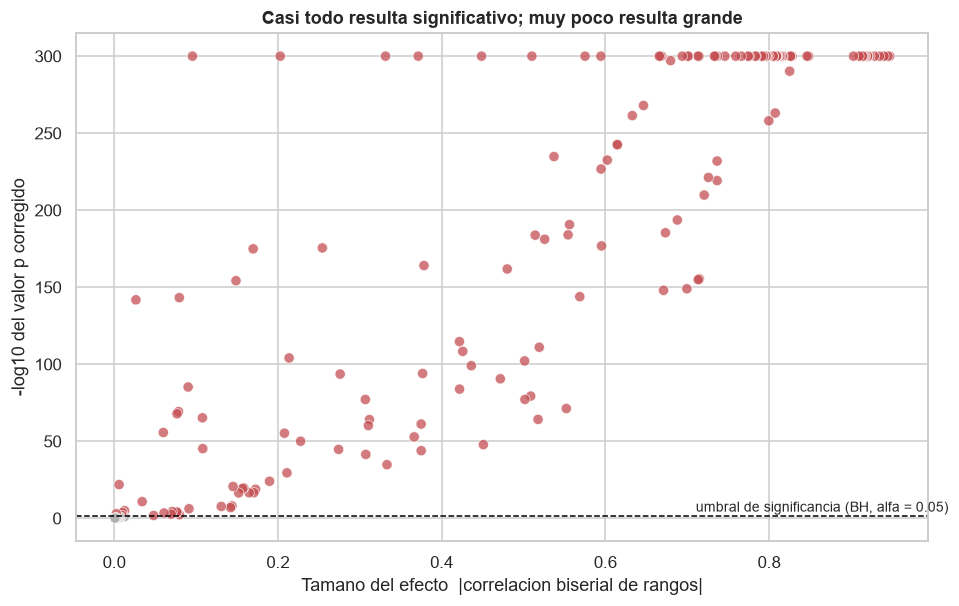

Lecturas significativas tras correccion pero con efecto pequeno (|r| < 0.10): 21
Lecturas con efecto apreciable (|r| >= 0.30): 115


In [33]:
plt.figure(figsize=(10, 6))

colores = np.where(contraste["significativa_bh"], "#C44E52", "#B0B0B0")
plt.scatter(
    contraste["magnitud"],
    -np.log10(contraste["valor_p_bh"].clip(lower=1e-300)),
    c=colores, alpha=0.75, s=45, edgecolors="white", linewidths=0.5,
)
plt.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=1)
plt.text(contraste["magnitud"].max() * 0.75, -np.log10(0.05) + 3,
         "umbral de significancia (BH, alfa = 0.05)", fontsize=9)
plt.xlabel("Tamano del efecto  |correlacion biserial de rangos|")
plt.ylabel("-log10 del valor p corregido")
plt.title("Casi todo resulta significativo; muy poco resulta grande")
guardar_figura("13_significancia_vs_magnitud")
plt.show()

print("Lecturas significativas tras correccion pero con efecto pequeno (|r| < 0.10):",
      int(((contraste["significativa_bh"]) & (contraste["magnitud"] < 0.10)).sum()))
print("Lecturas con efecto apreciable (|r| >= 0.30):",
      int((contraste["magnitud"] >= 0.30).sum()))

In [34]:
# Jerarquia de lecturas por capacidad de separacion
columnas_reporte = [
    "variable", "familia", "n_con_falla", "mediana_con_falla",
    "mediana_sin_falla", "r_biserial", "valor_p_bh", "significativa_bh",
]

print("Las veinticinco lecturas que mejor separan los dos grupos de vehiculos:")
print(
    contraste.head(25)[columnas_reporte]
    .round({"mediana_con_falla": 1, "mediana_sin_falla": 1, "r_biserial": 3})
    .assign(valor_p_bh=lambda t: t["valor_p_bh"].map("{:.2e}".format))
    .to_string(index=False)
)

Las veinticinco lecturas que mejor separan los dos grupos de vehiculos:
variable familia  n_con_falla  mediana_con_falla  mediana_sin_falla  r_biserial valor_p_bh  significativa_bh
  ci_000      ci          990         36076429.9          1824220.8       0.947   0.00e+00              True
  ck_000      ck          990          6848688.5           242316.5       0.945   0.00e+00              True
  bt_000      bt          989           585163.4            30471.9       0.940   0.00e+00              True
  aa_000      aa         1000           584994.0            30416.0       0.935   0.00e+00              True
  bj_000      bj          960          6044796.0           149962.0       0.929   0.00e+00              True
  ap_000      ap          957         11195058.0           347838.0       0.923   0.00e+00              True
  dn_000      dn          958           355244.0            13964.0       0.921   0.00e+00              True
  bb_000      bb          959         47370562.0        

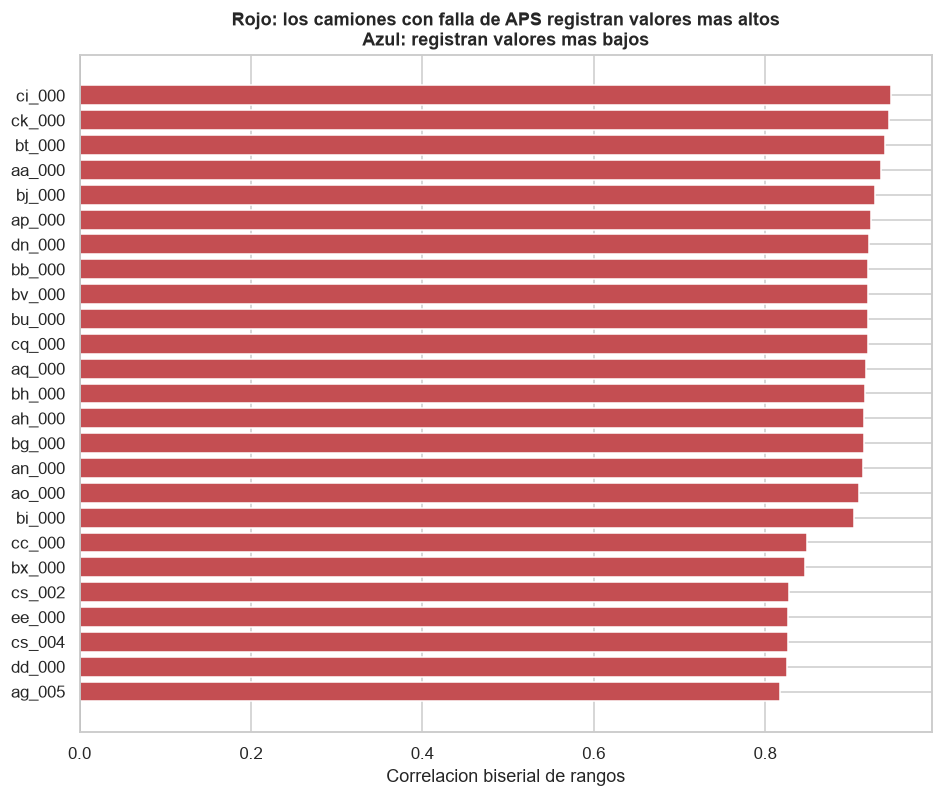

In [35]:
top_efecto = contraste.head(25).iloc[::-1]

plt.figure(figsize=(10, 8))
colores_barra = np.where(top_efecto["r_biserial"] > 0, "#C44E52", "#4C72B0")
plt.barh(top_efecto["variable"], top_efecto["r_biserial"], color=colores_barra)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Correlacion biserial de rangos")
plt.title(
    "Rojo: los camiones con falla de APS registran valores mas altos\n"
    "Azul: registran valores mas bajos"
)
guardar_figura("14_ranking_efecto")
plt.show()

### 15.2 Como se ven las lecturas que mejor separan

El estadistico resume, pero la decision de inspeccion depende de la forma
concreta de la separacion. Para las seis lecturas de mayor efecto se comparan
las distribuciones de los dos grupos, normalizadas cada una a su propio total
—de otro modo el grupo con falla, sesenta veces menor, seria invisible— y en
escala logaritmica, por la extension de las colas.

La funcion de distribucion acumulada que acompana a cada histograma es la que
importa para el taller: la separacion vertical entre las dos curvas en un valor
dado indica cuantos vehiculos de cada grupo quedarian por encima de ese umbral
si se usara esa lectura como criterio de inspeccion.

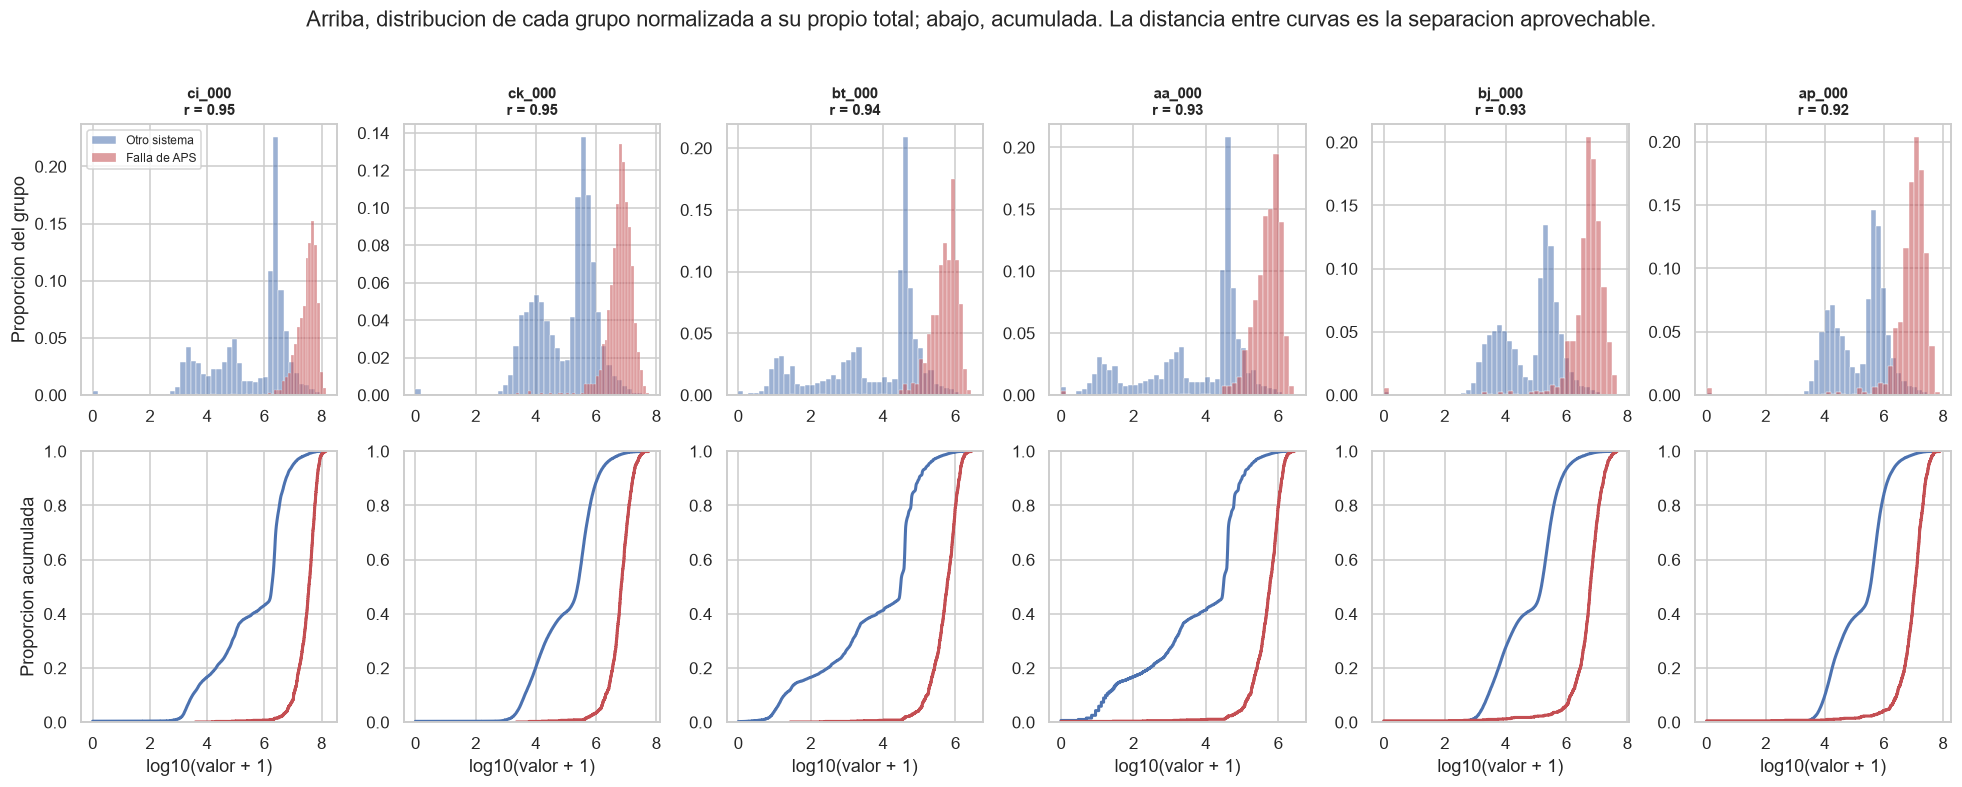

In [36]:
top_seis = contraste.head(6)["variable"].tolist()

fig, ejes = plt.subplots(2, 6, figsize=(18, 7))

for j, columna in enumerate(top_seis):
    serie_pos = df.loc[mascara_positivos, columna].dropna()
    serie_neg = df.loc[~mascara_positivos, columna].dropna()

    log_pos = np.log10(serie_pos + 1)
    log_neg = np.log10(serie_neg + 1)

    sns.histplot(log_neg, bins=45, stat="probability", ax=ejes[0, j],
                 color="#4C72B0", alpha=0.55, label="Otro sistema")
    sns.histplot(log_pos, bins=45, stat="probability", ax=ejes[0, j],
                 color="#C44E52", alpha=0.55, label="Falla de APS")
    r = contraste.loc[contraste["variable"] == columna, "r_biserial"].iloc[0]
    ejes[0, j].set_title(f"{columna}\nr = {r:.2f}", fontsize=10)
    ejes[0, j].set_xlabel("")
    ejes[0, j].set_ylabel("Proporcion del grupo" if j == 0 else "")
    if j == 0:
        ejes[0, j].legend(fontsize=8)

    sns.ecdfplot(log_neg, ax=ejes[1, j], color="#4C72B0", linewidth=2)
    sns.ecdfplot(log_pos, ax=ejes[1, j], color="#C44E52", linewidth=2)
    ejes[1, j].set_xlabel("log10(valor + 1)")
    ejes[1, j].set_ylabel("Proporcion acumulada" if j == 0 else "")

fig.suptitle(
    "Arriba, distribucion de cada grupo normalizada a su propio total; "
    "abajo, acumulada. La distancia entre curvas es la separacion aprovechable.",
    y=1.02,
)
plt.tight_layout()
guardar_figura("15_distribuciones_por_clase")
plt.show()

### 15.3 Los sensores de histograma, comparados por grupo

La seccion 10 mostro la forma del perfil de cada sensor de histograma en el
conjunto completo. La pregunta ahora es si esa forma cambia entre los dos grupos
de vehiculos: no si el sensor registra mas, sino si registra **en otra parte de
su rango**. Un desplazamiento del perfil es un tipo de senal que el analisis
columna por columna no captura.

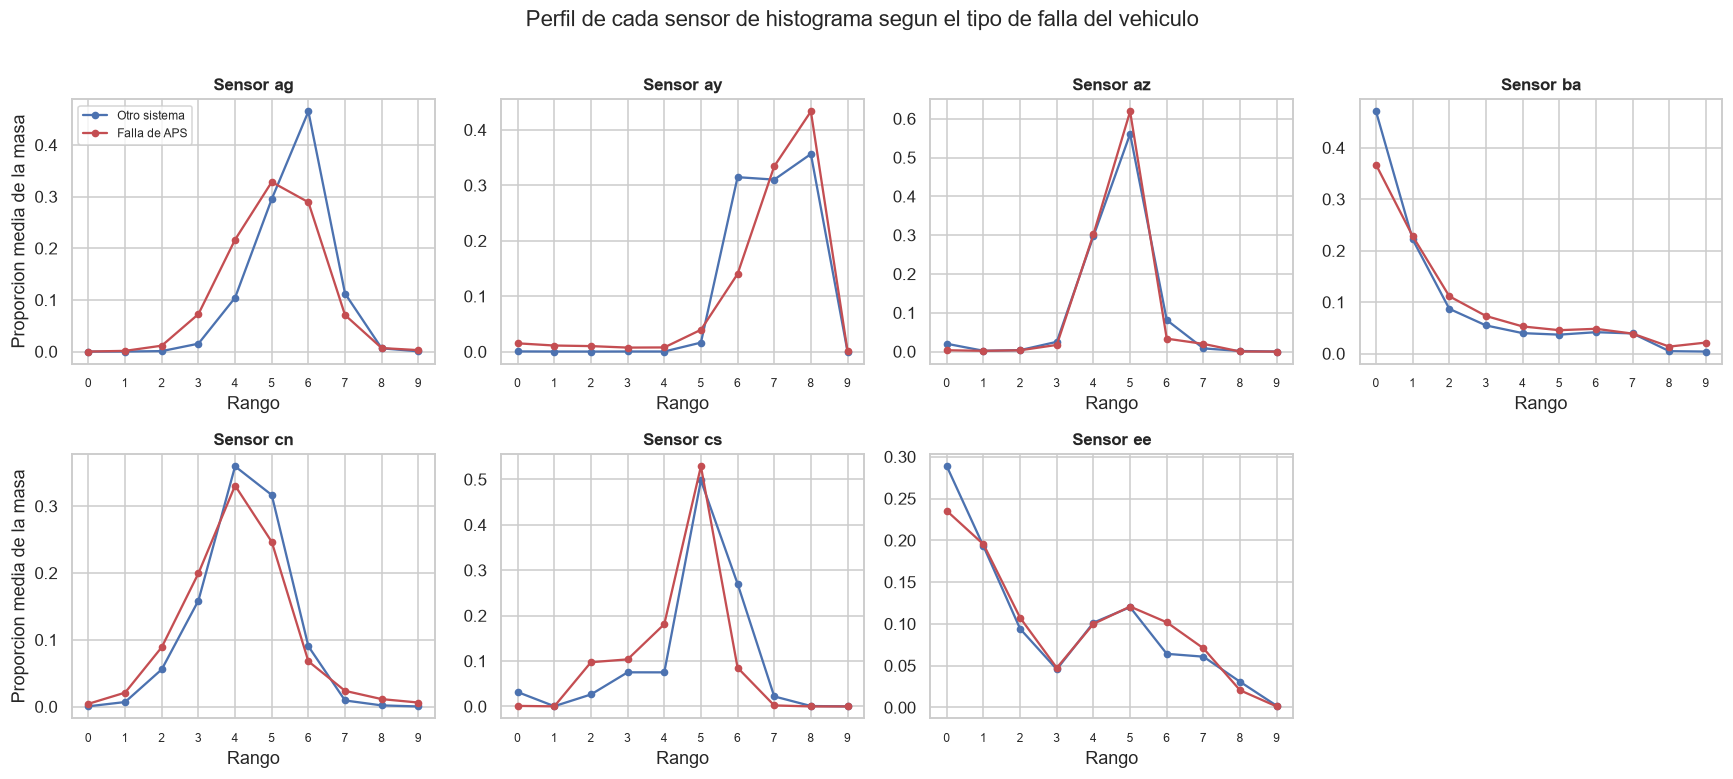

In [37]:
fig, ejes = plt.subplots(2, 4, figsize=(16, 7))
ejes = ejes.ravel()

for k, familia in enumerate(FAMILIAS_HISTOGRAMA):
    columnas_fam = sorted([c for c in VARIABLES if prefijos[c] == familia])
    bloque = df[columnas_fam]
    total_fila = bloque.sum(axis=1, min_count=1)
    validos = total_fila > 0

    proporciones = bloque.loc[validos].div(total_fila.loc[validos], axis=0)
    etiqueta = y.loc[validos]

    perfil_neg = proporciones.loc[etiqueta == 0].mean()
    perfil_pos = proporciones.loc[etiqueta == 1].mean()

    posiciones = np.arange(len(columnas_fam))
    ejes[k].plot(posiciones, perfil_neg.to_numpy(), marker="o", markersize=4,
                 color="#4C72B0", label="Otro sistema")
    ejes[k].plot(posiciones, perfil_pos.to_numpy(), marker="o", markersize=4,
                 color="#C44E52", label="Falla de APS")
    ejes[k].set_title(f"Sensor {familia}", fontsize=11)
    ejes[k].set_xlabel("Rango")
    ejes[k].set_ylabel("Proporcion media de la masa" if k % 4 == 0 else "")
    ejes[k].set_xticks(posiciones)
    ejes[k].set_xticklabels(posiciones, fontsize=8)
    if k == 0:
        ejes[k].legend(fontsize=8)

for k in range(len(FAMILIAS_HISTOGRAMA), len(ejes)):
    ejes[k].axis("off")

fig.suptitle(
    "Perfil de cada sensor de histograma segun el tipo de falla del vehiculo",
    y=1.01,
)
plt.tight_layout()
guardar_figura("16_perfiles_familias_por_clase")
plt.show()

## 16. Redundancia entre las lecturas mas informativas

Una lectura puede separar bien los grupos y aun asi no aportar nada, si lo que
dice ya lo dice otra. Esta seccion examina cuanta informacion distinta hay entre
las lecturas de mayor efecto.

Coherentemente con lo establecido en la seccion 9, se usa la correlacion de
**Spearman**: la verificacion de supuestos descarto la normalidad, y Pearson
seria inapropiado sobre distribuciones con estas colas. Y coherentemente con la
seccion 13, cada coeficiente se acompana de su valor p corregido por
Benjamini-Hochberg y la tabla se ordena por magnitud.

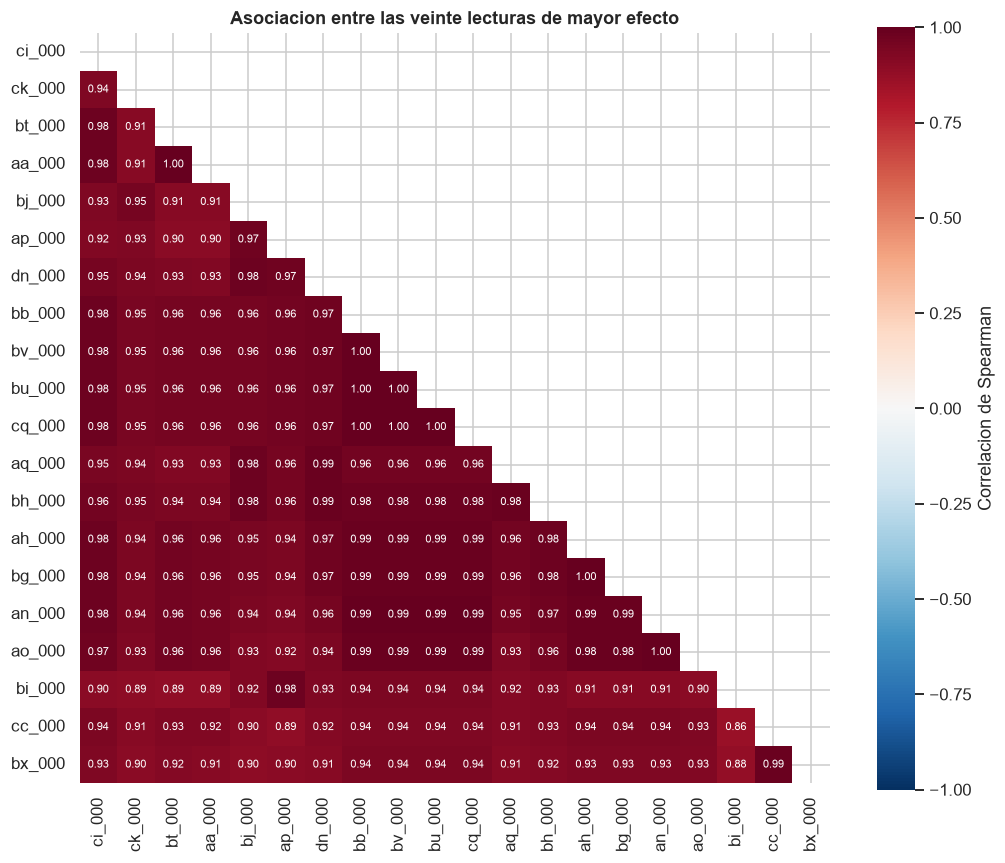

In [38]:
variables_top = contraste.head(20)["variable"].tolist()

matriz_spearman = df[variables_top].corr(method="spearman")

mascara_superior = np.triu(np.ones(matriz_spearman.shape, dtype=bool))

plt.figure(figsize=(11, 9))
sns.heatmap(
    matriz_spearman, mask=mascara_superior, cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 7},
    square=True, cbar_kws={"label": "Correlacion de Spearman"},
)
plt.title("Asociacion entre las veinte lecturas de mayor efecto")
guardar_figura("17_spearman_top")
plt.show()

In [39]:
# Coeficientes con su significancia, corregida por comparaciones multiples
filas_pares = []

for i in range(len(variables_top)):
    for j in range(i + 1, len(variables_top)):
        a, b = variables_top[i], variables_top[j]
        pareja = df[[a, b]].dropna()
        if len(pareja) < 30 or pareja[a].nunique() < 2 or pareja[b].nunique() < 2:
            continue
        rho, valor_p = stats.spearmanr(pareja[a], pareja[b])
        filas_pares.append(
            {
                "variable_1": a, "variable_2": b, "n": len(pareja),
                "rho_spearman": rho, "valor_p": valor_p,
                "misma_familia": prefijos[a] == prefijos[b],
            }
        )

pares_spearman = pd.DataFrame(filas_pares)

rechazo, p_ajustado, _, _ = multipletests(
    pares_spearman["valor_p"].to_numpy(), alpha=0.05, method="fdr_bh"
)
pares_spearman["valor_p_bh"] = p_ajustado
pares_spearman["significativa_bh"] = rechazo
pares_spearman["magnitud"] = pares_spearman["rho_spearman"].abs()

pares_spearman = pares_spearman.sort_values("magnitud", ascending=False).reset_index(drop=True)

print(f"Pares evaluados: {len(pares_spearman)}")
print(f"Significativos tras Benjamini-Hochberg: {int(pares_spearman['significativa_bh'].sum())}",
      f"({100 * pares_spearman['significativa_bh'].mean():.1f} %)")
print(f"Pares con asociacion fuerte (|rho| > 0.90): {int((pares_spearman['magnitud'] > 0.90).sum())}")
print(f"  de ellos, dentro de una misma familia de histograma: "
      f"{int(((pares_spearman['magnitud'] > 0.90) & pares_spearman['misma_familia']).sum())}")
print()
print("Los quince pares mas asociados, ordenados por magnitud:")
print(
    pares_spearman.head(15)
    .round({"rho_spearman": 3})
    .assign(valor_p_bh=lambda t: t["valor_p_bh"].map("{:.2e}".format))
    [["variable_1", "variable_2", "n", "rho_spearman", "valor_p_bh",
      "significativa_bh", "misma_familia"]]
    .to_string(index=False)
)

Pares evaluados: 190
Significativos tras Benjamini-Hochberg: 190 (100.0 %)
Pares con asociacion fuerte (|rho| > 0.90): 183
  de ellos, dentro de una misma familia de histograma: 0

Los quince pares mas asociados, ordenados por magnitud:
variable_1 variable_2     n  rho_spearman valor_p_bh  significativa_bh  misma_familia
    ah_000     bg_000 59323         1.000   0.00e+00              True          False
    bv_000     cq_000 59309         1.000   0.00e+00              True          False
    bb_000     bv_000 59283         1.000   0.00e+00              True          False
    bb_000     cq_000 59283         1.000   0.00e+00              True          False
    bu_000     cq_000 59309         1.000   0.00e+00              True          False
    bv_000     bu_000 59309         1.000   0.00e+00              True          False
    bb_000     bu_000 59283         1.000   0.00e+00              True          False
    bt_000     aa_000 59833         1.000   0.00e+00              True     

## 17. Sintesis orientada a la decision de inspeccion

Las secciones anteriores describen los datos. Esta traduce esa descripcion a los
terminos en que el taller toma la decision.

La seccion 6.7 establecio los dos extremos: no inspeccionar a nadie y
inspeccionar a toda la flota. Cualquier uso de estas lecturas solo se justifica
si logra situarse por debajo de ambos. El ejercicio siguiente **no es un modelo
ni pretende serlo**: toma la lectura de mayor efecto, la usa como criterio unico
de inspeccion recorriendo todos sus umbrales posibles, y calcula el costo de
operar asi. Es la version mas simple concebible de usar la informacion, y sirve
como piso: lo que un solo sensor consigue por si solo.

In [40]:
variable_referencia = contraste.iloc[0]["variable"]
serie_ref = df[variable_referencia]
disponible = serie_ref.notna()

valores = serie_ref[disponible].to_numpy()
etiquetas = y[disponible].to_numpy()

# Los vehiculos sin registro en esta lectura no pueden evaluarse con ella;
# se cuentan aparte como fallas potencialmente no detectadas.
n_sin_registro = int((~disponible).sum())
n_pos_sin_registro = int(y[~disponible].sum())

umbrales = np.unique(np.quantile(valores, np.linspace(0, 1, 200)))

filas_costo = []
for umbral in umbrales:
    inspeccionar = valores >= umbral
    verdaderos_positivos = int(((etiquetas == 1) & inspeccionar).sum())
    falsos_positivos = int(((etiquetas == 0) & inspeccionar).sum())
    falsos_negativos = int(((etiquetas == 1) & ~inspeccionar).sum()) + n_pos_sin_registro
    costo = (
        falsos_positivos * COSTO_INSPECCION_INNECESARIA
        + falsos_negativos * COSTO_FALLA_NO_DETECTADA
    )
    filas_costo.append(
        {
            "umbral": umbral,
            "vehiculos_inspeccionados": int(inspeccionar.sum()),
            "fallas_detectadas": verdaderos_positivos,
            "falsas_alarmas": falsos_positivos,
            "fallas_no_detectadas": falsos_negativos,
            "costo_total": costo,
        }
    )

curva_costo = pd.DataFrame(filas_costo)
mejor = curva_costo.loc[curva_costo["costo_total"].idxmin()]

print(f"Lectura utilizada como criterio unico: {variable_referencia}")
print(f"Vehiculos sin registro en esta lectura: {n_sin_registro:,}",
      f"(de ellos, {n_pos_sin_registro} con falla de APS)")
print()
print("Mejor umbral encontrado para esta lectura por si sola:")
print(mejor.round(2).to_string())
print()
print("Comparacion con las estrategias de referencia:")
comparacion_costos = pd.DataFrame(
    {
        "estrategia": [
            "No inspeccionar ningun vehiculo",
            "Inspeccionar toda la flota",
            f"Inspeccionar segun {variable_referencia}",
        ],
        "costo_total": [
            costo_no_inspeccionar,
            costo_inspeccionar_todo,
            int(mejor["costo_total"]),
        ],
    }
)
comparacion_costos["costo_por_vehiculo"] = (
    comparacion_costos["costo_total"] / len(df)
).round(2)
comparacion_costos["reduccion_vs_peor_pct"] = (
    100 * (1 - comparacion_costos["costo_total"] / comparacion_costos["costo_total"].max())
).round(1)
print(comparacion_costos.to_string(index=False))

Lectura utilizada como criterio unico: ci_000
Vehiculos sin registro en esta lectura: 338 (de ellos, 10 con falla de APS)

Mejor umbral encontrado para esta lectura por si sola:
umbral                      9261637.58
vehiculos_inspeccionados       4198.00
fallas_detectadas               915.00
falsas_alarmas                 3283.00
fallas_no_detectadas             85.00
costo_total                   75330.00

Comparacion con las estrategias de referencia:
                     estrategia  costo_total  costo_por_vehiculo  reduccion_vs_peor_pct
No inspeccionar ningun vehiculo       500000                8.33                   15.3
     Inspeccionar toda la flota       590000                9.83                    0.0
      Inspeccionar segun ci_000        75330                1.26                   87.2


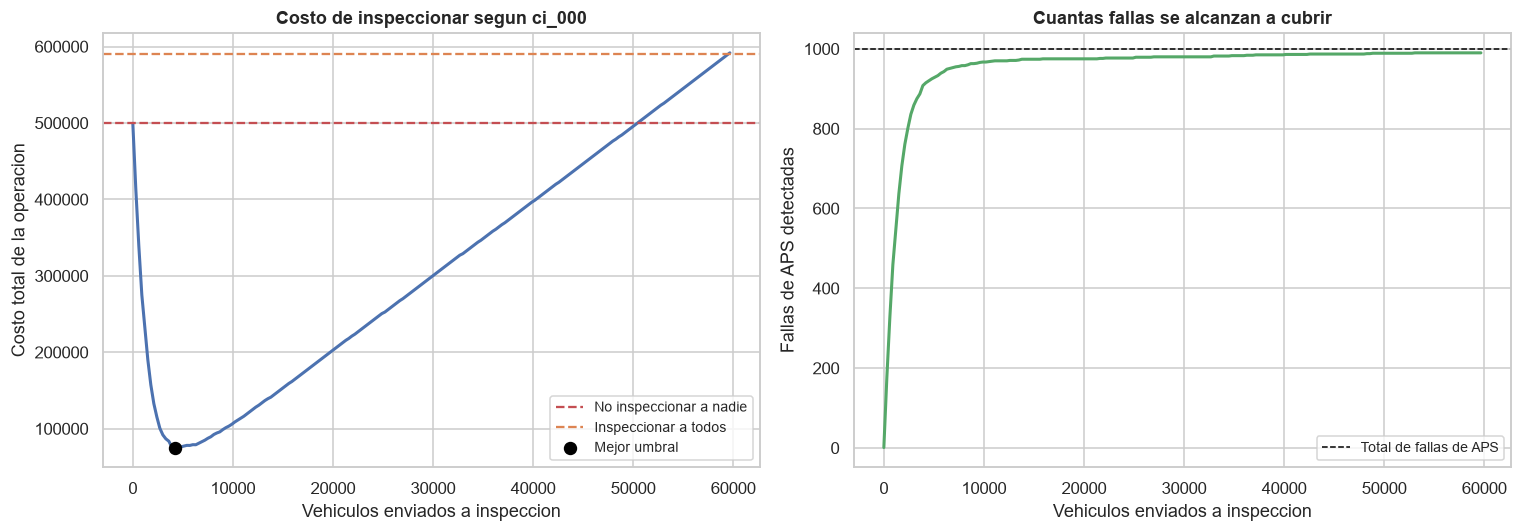

In [41]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

ejes[0].plot(curva_costo["vehiculos_inspeccionados"], curva_costo["costo_total"],
             color="#4C72B0", linewidth=2)
ejes[0].axhline(costo_no_inspeccionar, color="#C44E52", linestyle="--",
                linewidth=1.5, label="No inspeccionar a nadie")
ejes[0].axhline(costo_inspeccionar_todo, color="#DD8452", linestyle="--",
                linewidth=1.5, label="Inspeccionar a todos")
ejes[0].scatter([mejor["vehiculos_inspeccionados"]], [mejor["costo_total"]],
                color="black", zorder=5, s=60, label="Mejor umbral")
ejes[0].set_xlabel("Vehiculos enviados a inspeccion")
ejes[0].set_ylabel("Costo total de la operacion")
ejes[0].set_title(f"Costo de inspeccionar segun {variable_referencia}")
ejes[0].legend(fontsize=9)

ejes[1].plot(curva_costo["vehiculos_inspeccionados"], curva_costo["fallas_detectadas"],
             color="#55A868", linewidth=2)
ejes[1].axhline(n_pos, color="black", linestyle="--", linewidth=1,
                label="Total de fallas de APS")
ejes[1].set_xlabel("Vehiculos enviados a inspeccion")
ejes[1].set_ylabel("Fallas de APS detectadas")
ejes[1].set_title("Cuantas fallas se alcanzan a cubrir")
ejes[1].legend(fontsize=9)

plt.tight_layout()
guardar_figura("18_curva_costo")
plt.show()

In [42]:
# Tabla final: jerarquia de lecturas para la decision de inspeccion
sintesis = contraste.head(30)[
    ["variable", "familia", "r_biserial", "valor_p_bh", "significativa_bh"]
].copy()
sintesis = sintesis.merge(
    resumen[["pct_faltantes", "pct_ceros", "mediana"]].reset_index(),
    on="variable", how="left",
)
sintesis["direccion"] = np.where(
    sintesis["r_biserial"] > 0,
    "mas alto con falla de APS",
    "mas bajo con falla de APS",
)
sintesis["tipo_lectura"] = np.where(
    sintesis["variable"].isin(COLUMNAS_HISTOGRAMA), "rango de histograma", "medicion simple"
)
sintesis = sintesis[
    ["variable", "familia", "tipo_lectura", "r_biserial", "direccion",
     "valor_p_bh", "pct_faltantes", "pct_ceros"]
].round({"r_biserial": 3, "pct_faltantes": 1, "pct_ceros": 1})

sintesis.to_csv(os.path.join(RUTA_INTERIM, "sintesis_lecturas.csv"), index=False)

print("Jerarquia de lecturas para la decision de inspeccion:")
sintesis

Jerarquia de lecturas para la decision de inspeccion:


,variable,familia,tipo_lectura,r_biserial,direccion,valor_p_bh,pct_faltantes,pct_ceros
0,ci_000,ci,medicion simple,0.947,mas alto con falla de APS,0.000000e+00,0.6,0.4
1,ck_000,ck,medicion simple,0.945,mas alto con falla de APS,0.000000e+00,0.6,0.3
2,bt_000,bt,medicion simple,0.940,mas alto con falla de APS,0.000000e+00,0.3,0.2
3,aa_000,aa,medicion simple,0.935,mas alto con falla de APS,0.000000e+00,0.0,0.7
4,bj_000,bj,medicion simple,0.929,mas alto con falla de APS,0.000000e+00,1.0,0.2
5,ap_000,ap,medicion simple,0.923,mas alto con falla de APS,0.000000e+00,1.1,0.2
6,dn_000,dn,medicion simple,0.921,mas alto con falla de APS,0.000000e+00,1.2,0.2
7,bb_000,bb,medicion simple,0.921,mas alto con falla de APS,0.000000e+00,1.1,0.2
8,bv_000,bv,medicion simple,0.920,mas alto con falla de APS,0.000000e+00,1.2,0.2
9,bu_000,bu,medicion simple,0.920,mas alto con falla de APS,0.000000e+00,1.2,0.2


## 18. Conclusiones

La exploración responde afirmativamente la pregunta que la motivaba: las
lecturas registradas a bordo **sí separan** a los camiones con falla del sistema
de aire comprimido de aquellos con fallas en otros sistemas, y lo hacen con un
margen amplio. Pero la respuesta viene acompañada de dos precisiones que cambian
sustancialmente lo que puede afirmarse.

### 18.1 Sobre la estructura y la calidad del registro

El registro está en buen estado para el uso que se le quiere dar. La ausencia
global de 8,33 % se concentra en un grupo acotado: ocho lecturas superan el 50 %
de vehículos sin registro y 24 superan el 20 %, mientras que la gran mayoría
reporta por encima del 95 %. Las setenta columnas que forman los sensores de
histograma —el 41 % del registro— están prácticamente completas.

La ausencia no es aleatoria ni individual. Se organiza en bloques que comparten
tasas idénticas hasta el segundo decimal, lo que indica subsistemas completos de
telemetría que dejan de reportar de forma conjunta. Para el taller esto es una
distinción útil: no hay que perseguir sensores sueltos averiados sino entender
por qué ciertos grupos de mediciones no llegan.

Una sola lectura, `cd_000`, es constante en los 60.000 vehículos y no aporta
información alguna.

### 18.2 Sobre la ausencia de datos

Ninguna de las diferencias en tasa de ausencia entre los dos grupos de vehículos
sobrevive a la corrección por comparaciones múltiples. Es decir: **que un sensor
no reporte no dice nada sobre si el camión tiene una falla de APS.**

El resultado es informativo en sí mismo y tiene una consecuencia práctica clara.
Las ocho lecturas con cobertura insuficiente pueden descartarse sin perder
señal, porque su ausencia es un problema de telemetría y no un síntoma del
vehículo. Si el resultado hubiera sido el contrario, descartarlas habría
significado tirar información valiosa.

### 18.3 Sobre la capacidad de las lecturas para separar los dos grupos

**La separación es real y grande.** De las 169 lecturas contrastables, 159
resultan significativas tras la corrección de Benjamini-Hochberg, y 115 alcanzan
un tamaño de efecto igual o superior a 0,30. La lectura de mayor efecto,
`ci_000`, alcanza una correlación biserial de rangos de 0,947: tomados al azar
un camión de cada grupo, esa sola lectura los ordena correctamente en cerca del
97 % de los casos.

**La significancia no aportó nada a la jerarquía.** El dato más elocuente del
análisis es que 159 lecturas resultan significativas antes de la corrección y
las mismas 159 después: Benjamini-Hochberg no eliminó ni una. Con 60.000
vehículos los valores p son tan extremos que la corrección resulta inmaterial y
la significancia deja por completo de discriminar. Hay 21 lecturas
estadísticamente significativas cuyo tamaño de efecto es inferior a 0,10 —
asociaciones que ninguna prueba rechazaría y que a ningún jefe de taller le
servirían para decidir nada. Ordenar por magnitud y no por valor p no fue una
formalidad metodológica: fue lo único que produjo una jerarquía utilizable.

**Las lecturas de mayor efecto son en buena medida la misma información
repetida.** Este es el hallazgo que más condiciona la interpretación. Entre las
veinte lecturas de mayor efecto, 183 de los 190 pares posibles correlacionan por
encima de 0,90, y ocho pares alcanzan exactamente 1,000. Se distinguen grupos
que son literalmente intercambiables:

- `bb_000`, `bu_000`, `bv_000` y `cq_000`, con correlación de 1,00 entre todos
  sus pares
- `ah_000` y `bg_000`, con correlación de 1,00
- `bt_000` y `aa_000`, con correlación de 1,00
- `an_000` y `ao_000`, con 0,997

Esas veinte lecturas no son veinte fuentes de evidencia sino, siendo generosos,
tres o cuatro. Y la redundancia no se explica por la estructura de familias de
histograma: ninguno de esos pares pertenece a una misma familia. Son sensores
con nombres distintos, y presumiblemente componentes distintos, que miden lo
mismo.

**Hipótesis sobre qué está midiendo esa señal.** Las dieciocho lecturas de mayor
efecto son mediciones simples, todas apuntan en la misma dirección —valores más
altos en los camiones con falla de APS—, todas tienen cobertura casi completa,
casi ningún cero, y umbrales que se sitúan en el orden de los millones. El
comportamiento es el de contadores acumulados. La explicación más económica es
que todas estén midiendo, en distintas unidades, la **exposición acumulada del
vehículo**: kilometraje, horas de operación o ciclos de trabajo.

Si esa hipótesis es correcta, lo que el análisis detecta no es un síntoma del
sistema de aire comprimido sino que **los camiones que fallan del APS son
sistemáticamente los más usados de la flota**. Esto no invalida el hallazgo: la
señal es real, es fuerte y sirve para decidir a quién inspeccionar. Pero cambia
lo que significa. Un sistema construido sobre esta señal estaría priorizando
vehículos por desgaste general, no detectando un deterioro específico del APS, y
por lo tanto podría estar señalando camiones que están a punto de fallar de
cualquier cosa.

El carácter anonimizado de las variables impide confirmar o descartar la
hipótesis con los datos disponibles. Resolverla requeriría acceso al diccionario
de variables o a información del vehículo que el registro no incluye.

### 18.4 Implicaciones para la decisión de inspección

**La información disponible reduce el costo de la operación de forma
sustancial.** El ejercicio de la sección 17 usa una sola lectura, `ci_000`, como
criterio único de inspección, sin ningún modelo. Con el umbral que minimiza el
costo se inspeccionarían 4.198 vehículos de los 60.000, se detectarían 915 de
las 1.000 fallas de APS y se generarían 3.283 falsas alarmas. El costo resultante
es de 75.330, frente a 500.000 de no inspeccionar a nadie y 590.000 de
inspeccionar a toda la flota: **una reducción del 85 % respecto de la mejor de
las dos alternativas sin información**, y de 8,33 a 1,26 unidades por vehículo.

**La estructura de costos justifica tolerar muchas falsas alarmas.** El umbral
óptimo genera 3,6 inspecciones innecesarias por cada falla detectada. Eso puede
parecer ineficiente hasta que se recuerda que la operación puede pagar hasta 50.
El margen sobrante es considerable y significa que hay espacio para bajar el
umbral —inspeccionar más camiones— si se quisiera cubrir las 85 fallas que este
criterio deja pasar. La curva de costo muestra además que el mínimo es plano en
una región amplia, de modo que la elección exacta del umbral no es crítica: el
taller puede ajustarlo según su capacidad de inspección sin penalización
importante.

**No hacen falta 170 sensores.** Dada la redundancia documentada más arriba, la
información utilizable se concentra en un número reducido de mediciones
distintas. Esto es una buena noticia operativa: significa que el registro puede
simplificarse considerablemente sin perder capacidad de decisión.

**Lo que este análisis no autoriza a concluir.** El ejercicio de costo evalúa un
solo umbral, elegido sobre los mismos vehículos con los que se calculó. Es una
referencia interna que establece un piso —lo que consigue una lectura por sí
sola— y no una estimación del desempeño que cabría esperar sobre vehículos
nuevos. Cualquier cifra de ahorro que se comprometa ante la operación debe
provenir de una evaluación sobre datos no utilizados en la construcción del
criterio.

### 18.5 Limitaciones del analisis

El caracter anonimizado de las lecturas impide toda validacion contra
conocimiento de ingenieria: no es posible confirmar si las lecturas que mejor
separan los grupos corresponden efectivamente a componentes del sistema de aire
comprimido, ni descartar que alguna asociacion fuerte provenga de un artefacto
del registro. Las conclusiones de este cuaderno son descriptivas y estan
condicionadas a que los datos hayan sido registrados de forma consistente
durante todo el periodo.

El registro tampoco incluye marca temporal, kilometraje, modelo de vehiculo ni
condiciones de operacion. Cualquier diferencia entre los dos grupos que provenga
de esas variables, y no del estado del APS, resulta indistinguible con la
informacion disponible.

Finalmente, el ejercicio de costo de la seccion 17 evalua una unica lectura como
criterio y sobre los mismos vehiculos que se usaron para elegir el umbral. Es
una referencia interna, no una estimacion del desempeno que cabria esperar sobre
vehiculos nuevos.